## Import necessary libraries and functions

In [1]:
import numpy as np
import tensorflow as tf
import tomllib

from TMA4900.simulator import Simulator
from TMA4900.priors import LatentStatePrior
from TMA4900.mcmc import ConditionalPosterior, LatentStateKernel

from TMA4900.utils import (
    evaluate_density_CTP, plot_marginal_densities, plot_contours, 
    evaluate_density_relative_eCTP, evaluate_density_relative_flow_rate,
    plot_likelihood, plot, sample_conditional_posteriors, 
    plot_prior_posterior_parameter_density, plot_posterior_height_over_time
)

## Prior plots

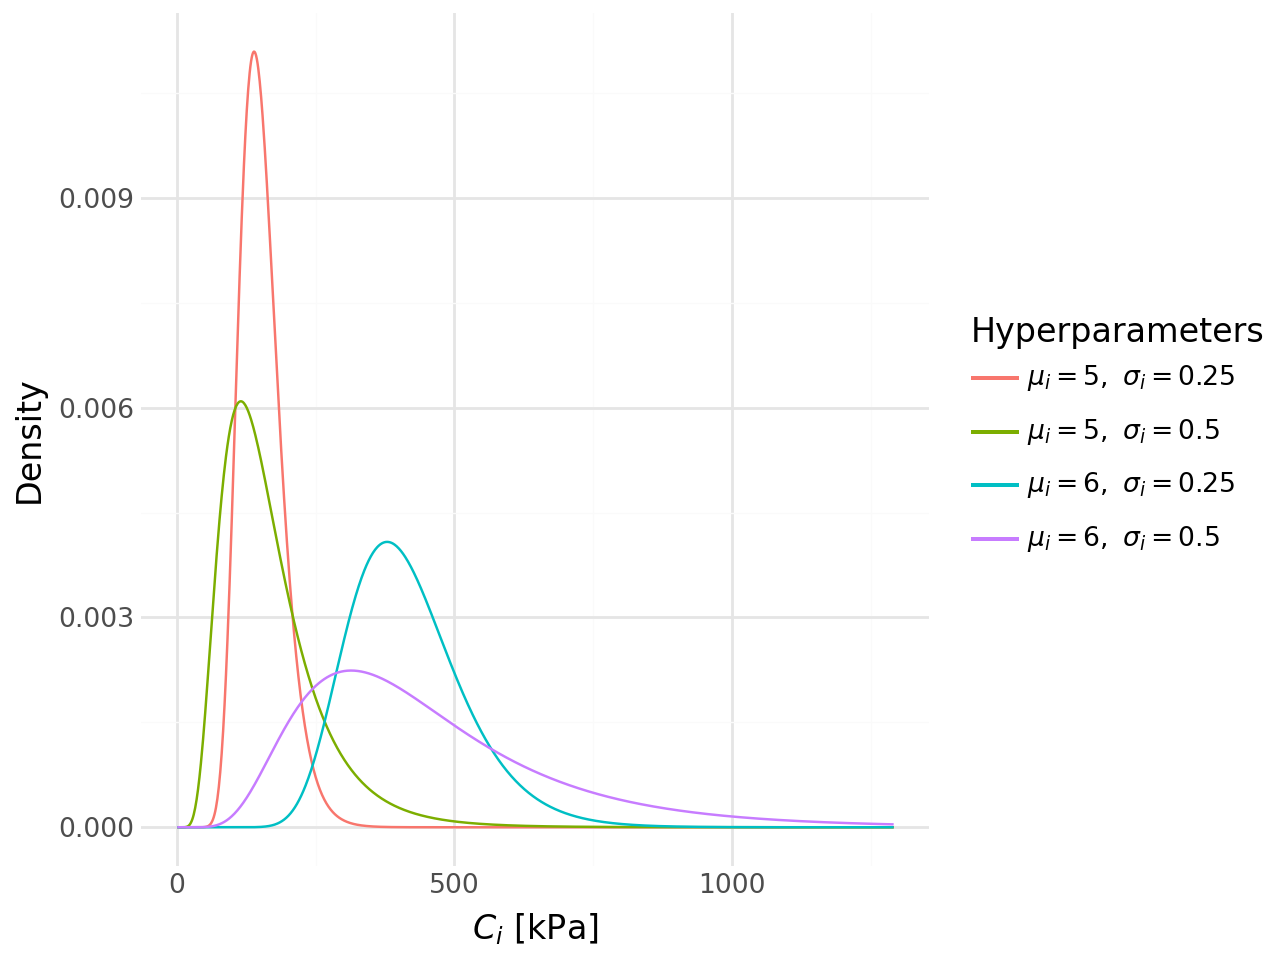

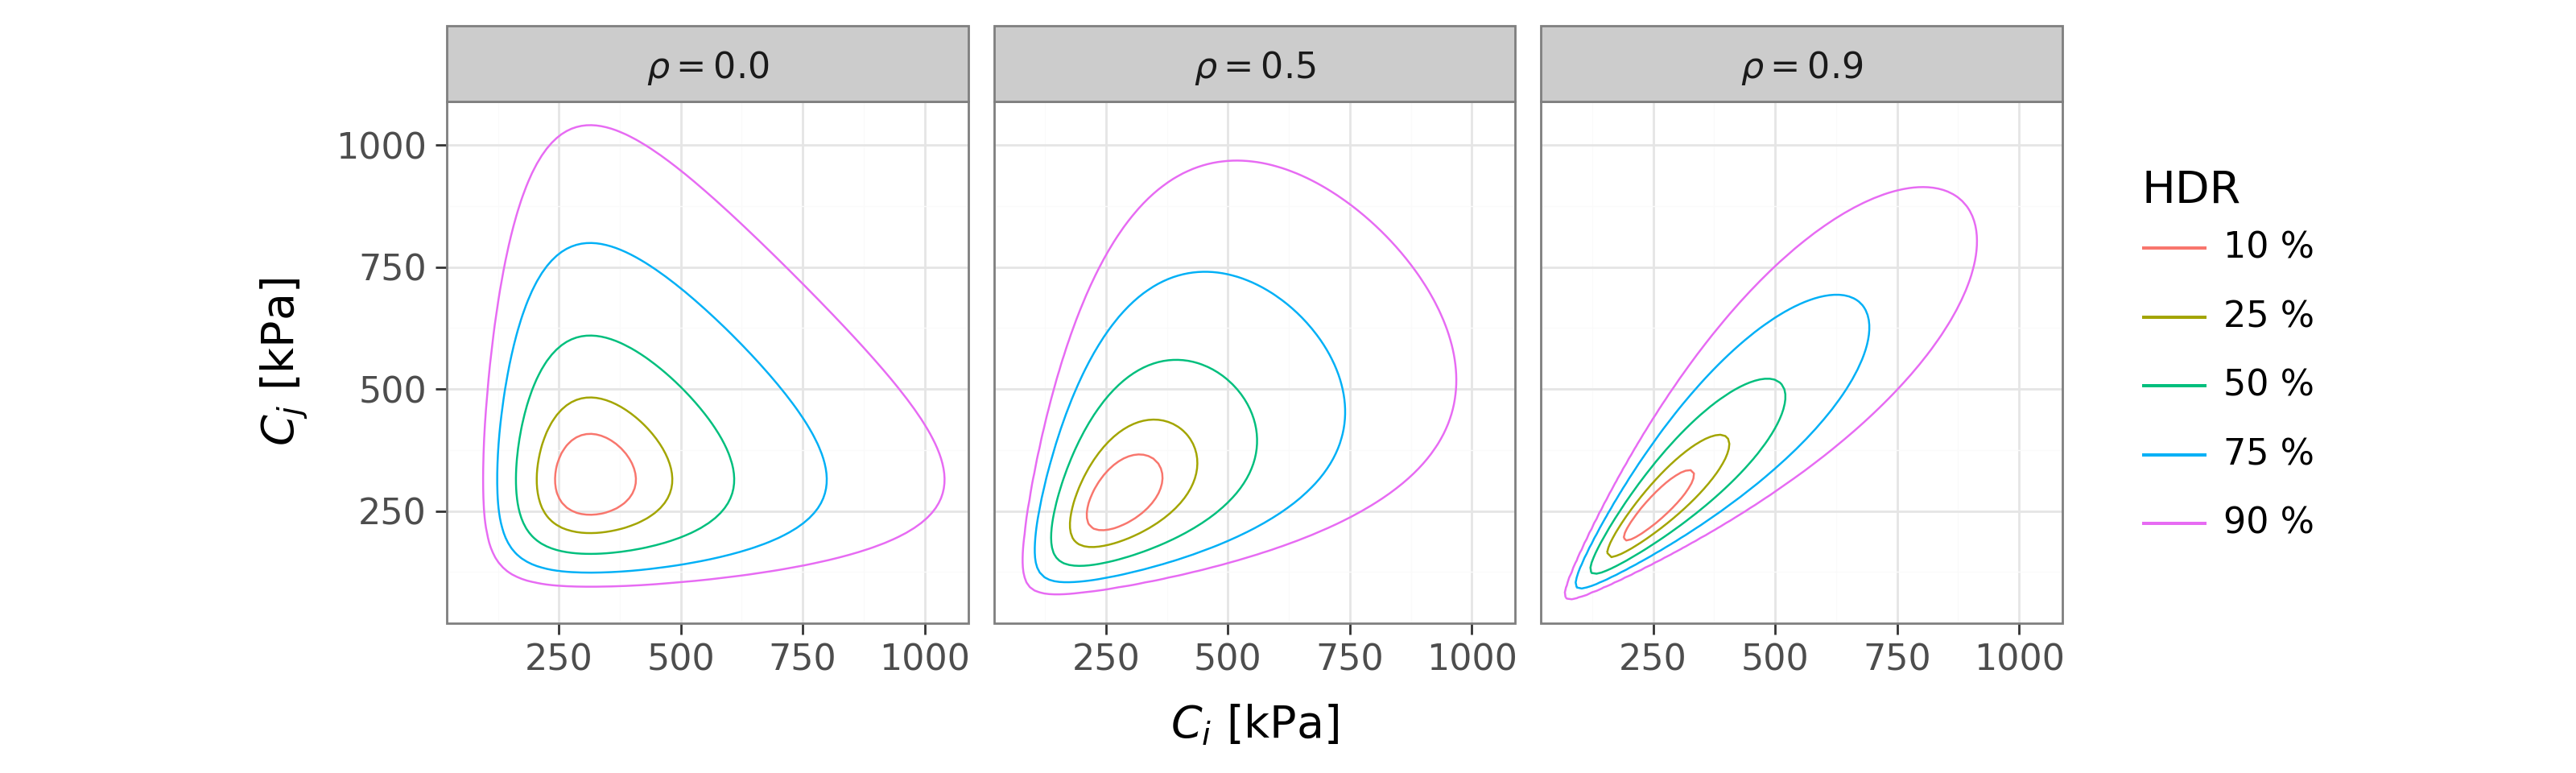

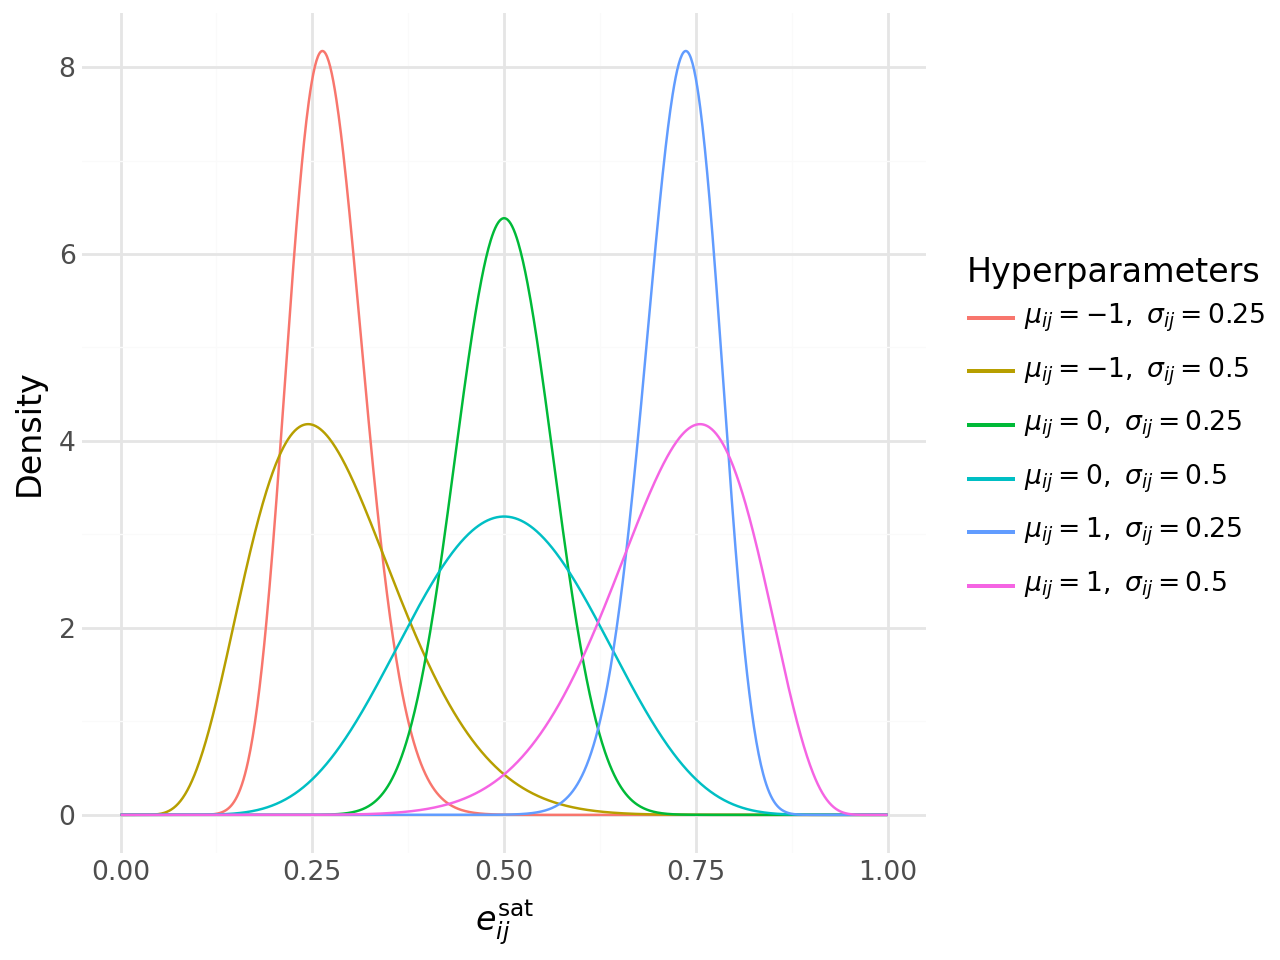

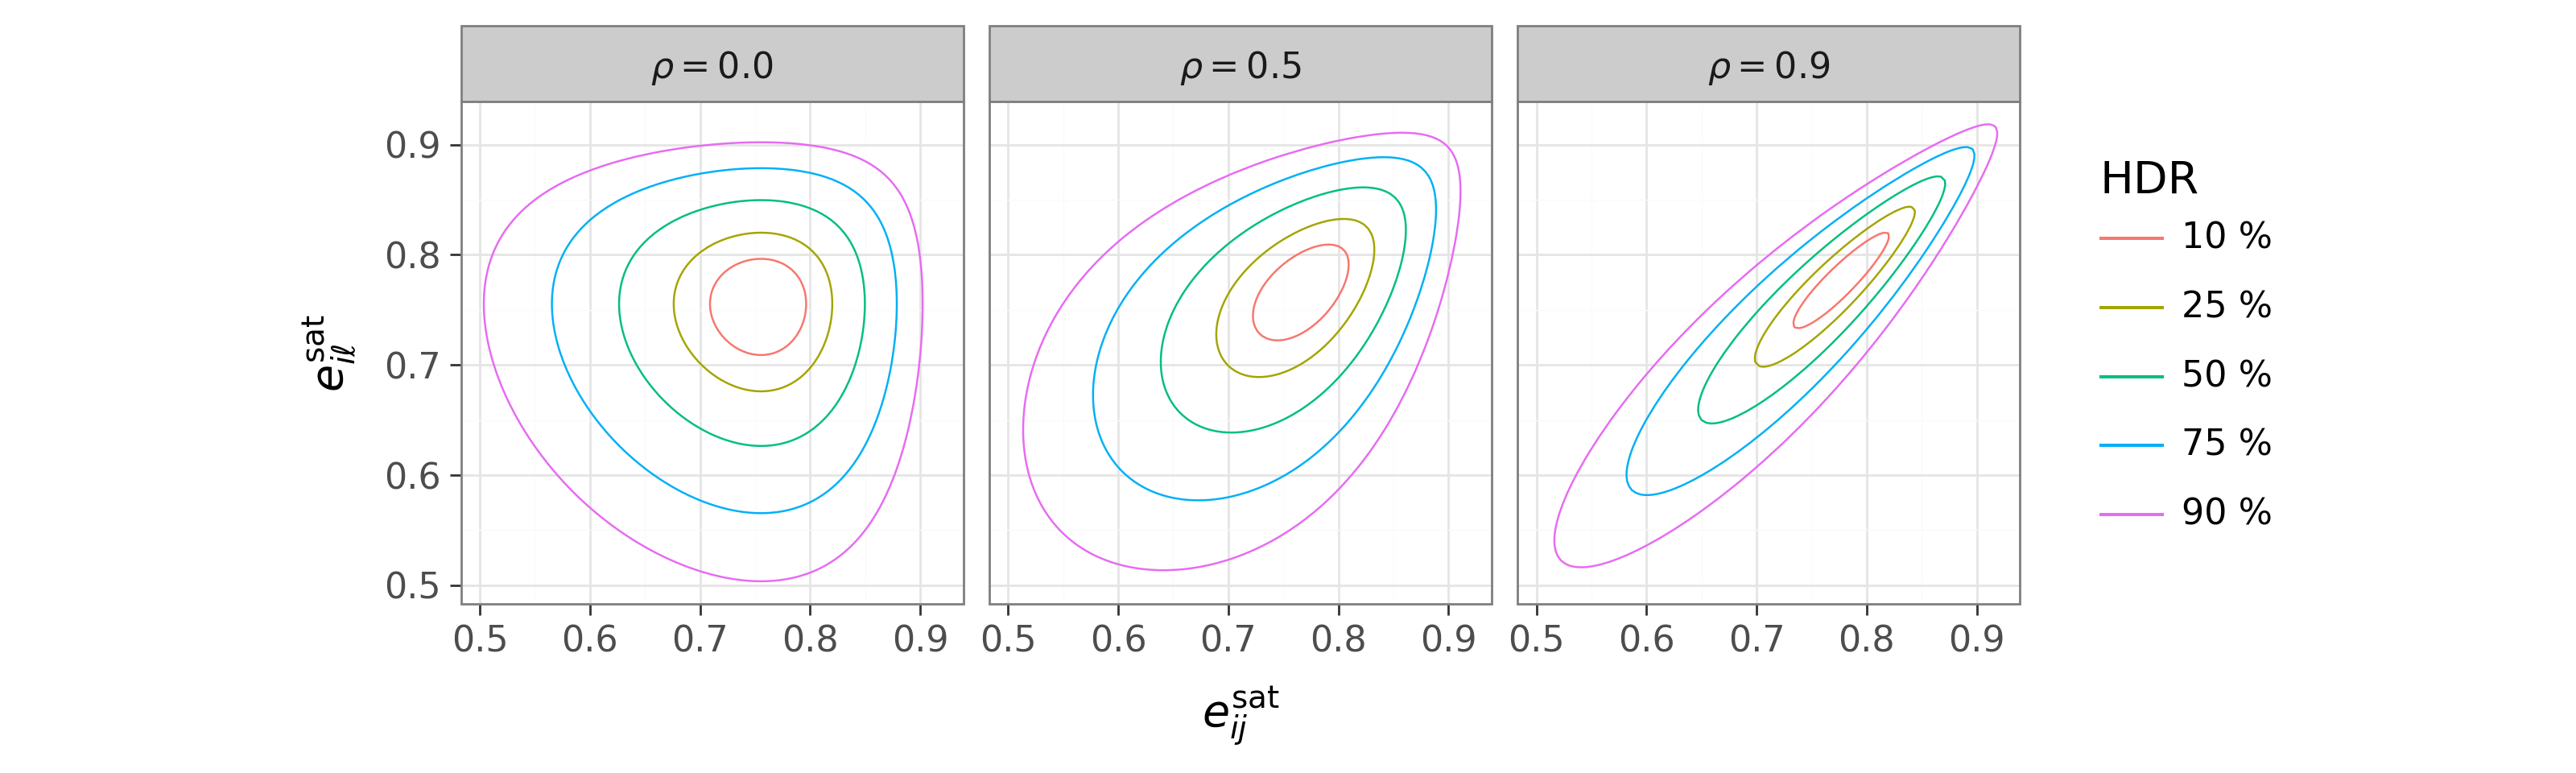

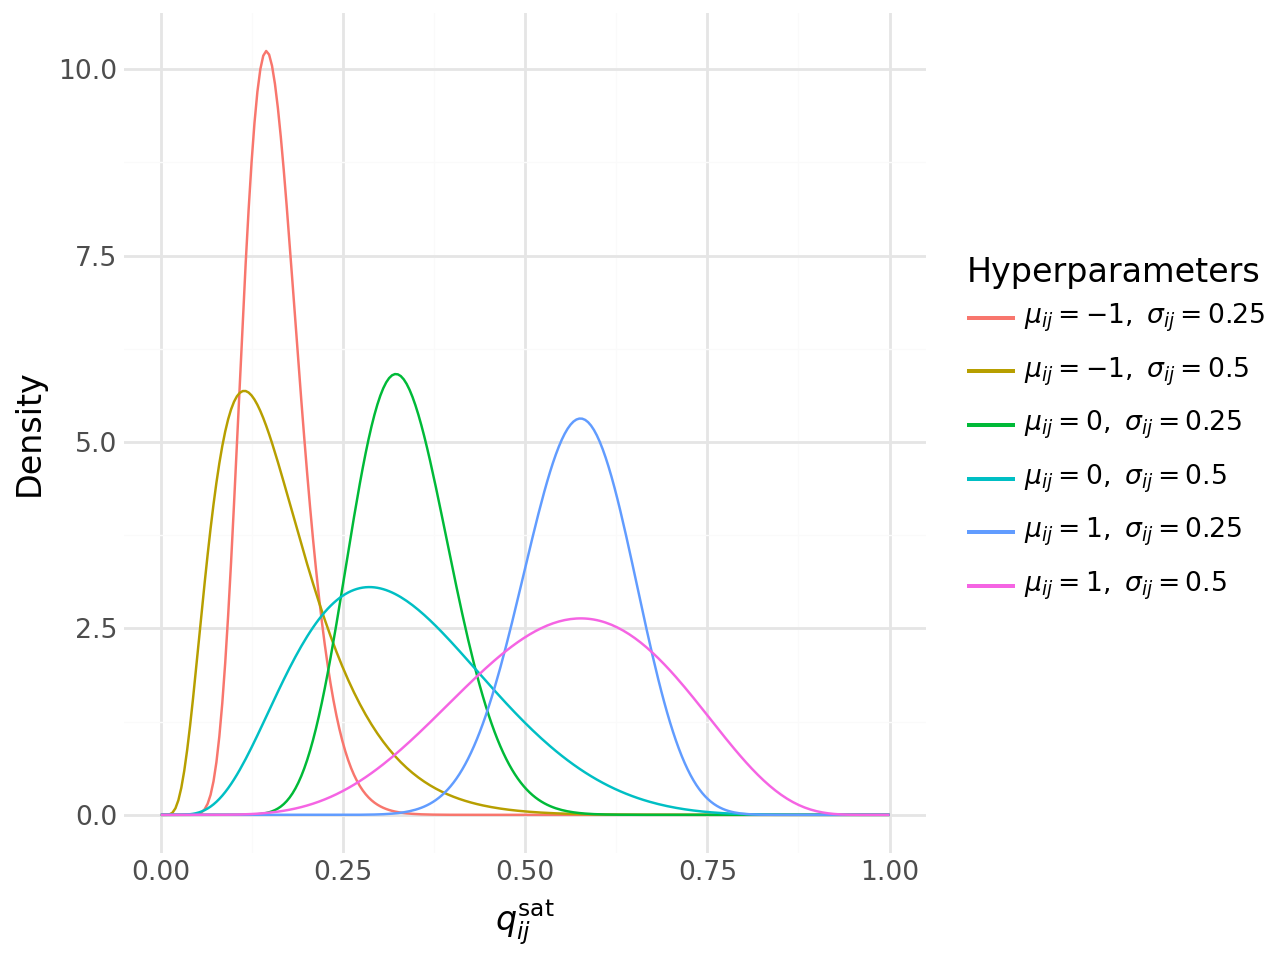

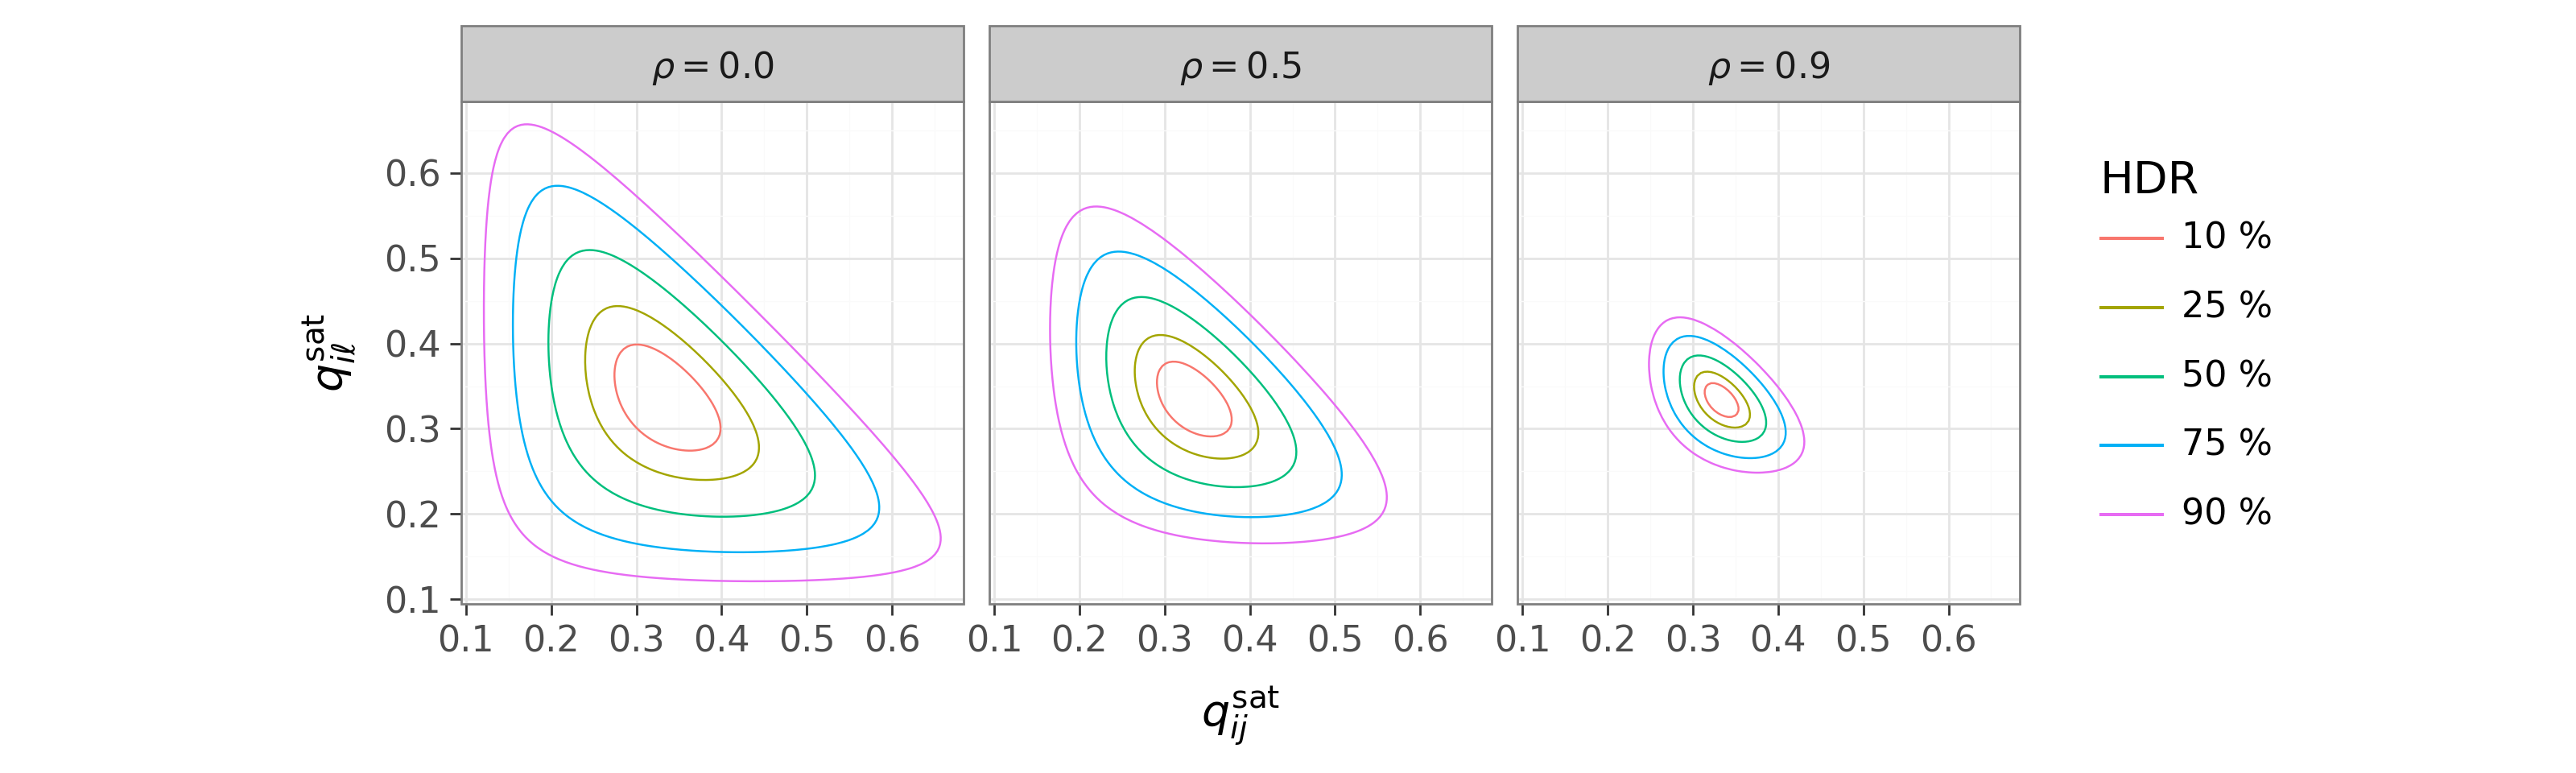

In [2]:
correlation=np.array((0.0, 0.5, 0.9))



CTP, prior_densities, density_labels = evaluate_density_CTP(
    unconstrained_mean=np.array((5, 6)),
    unconstrained_std=np.array((0.25, 0.5)),
    type="marginal"
)
marginal_plot = plot_marginal_densities(
    parameter=CTP,
    parameter_label=r"$C_i \ [\text{kPa}]$",
    prior_densities=prior_densities,
    density_labels=density_labels
)
marginal_plot.show()



x_axis, y_axis, prior_densities = evaluate_density_CTP(
    unconstrained_mean=np.array((6, 6)),
    unconstrained_std=np.array((0.5, 0.5)),
    correlation=correlation,
    type="joint"
)  
contour_plot = plot_contours(
    prior_densities=prior_densities,
    x_axis=x_axis,
    y_axis=y_axis,
    highest_density_regions=np.array((0.1, 0.25, 0.5, 0.75, 0.9)),
    correlation=correlation,
    parameter_labels=[r"$C_i \ [\text{kPa}]$", r"$C_j \ [\text{kPa}]$"]
)
contour_plot.show()



relative_eCTP, prior_densities, density_labels = evaluate_density_relative_eCTP(
    unconstrained_mean=np.array((-1, 0, 1)),
    unconstrained_std=np.array((0.25, 0.5)),
    type="marginal"
)
marginal_plot = plot_marginal_densities(
    parameter=relative_eCTP,
    parameter_label=r"$e_{ij}^{\text{sat}}$",
    prior_densities=prior_densities,
    density_labels=density_labels
)
marginal_plot.show()



x_axis, y_axis, prior_densities = evaluate_density_relative_eCTP(
    unconstrained_mean=np.array((1.0, 1.0)),
    unconstrained_std=np.array((0.5, 0.5)),
    correlation=correlation,
    type="joint"
)  
contour_plot = plot_contours(
    prior_densities=prior_densities,
    x_axis=x_axis,
    y_axis=y_axis,
    highest_density_regions=np.array((0.1, 0.25, 0.5, 0.75, 0.9)),
    correlation=correlation,
    parameter_labels=[r"$e_{ij}^{\text{sat}}$", r"$e_{i\ell}^{\text{sat}}$"]
)
contour_plot.show()



(relative_flow_rate, prior_densities, 
 density_labels) = evaluate_density_relative_flow_rate(
    unconstrained_mean=np.array((-1, 0, 1)),
    unconstrained_std=np.array((0.25, 0.5)),
    type="marginal"
)
marginal_plot = plot_marginal_densities(
    parameter=relative_flow_rate,
    parameter_label=r"$q_{ij}^\text{sat}$",
    prior_densities=prior_densities,
    density_labels=density_labels
)
marginal_plot.show()



x_axis, y_axis, prior_densities = evaluate_density_relative_flow_rate(
    unconstrained_mean=np.array((0, 0, 0)),
    unconstrained_std=np.array((0.5, 0.5, 0.5)),
    type="joint",
    correlation=correlation
)
contour_plot = plot_contours(
    prior_densities=prior_densities,
    x_axis=x_axis,
    y_axis=y_axis,
    highest_density_regions=np.array((0.1, 0.25, 0.5, 0.75, 0.9)),
    correlation=correlation,
    parameter_labels=[r"$q_{ij}^\text{sat}$", r"$q_{i\ell}^\text{sat}$"]
)
contour_plot.show()


## Acquisition Model Plot

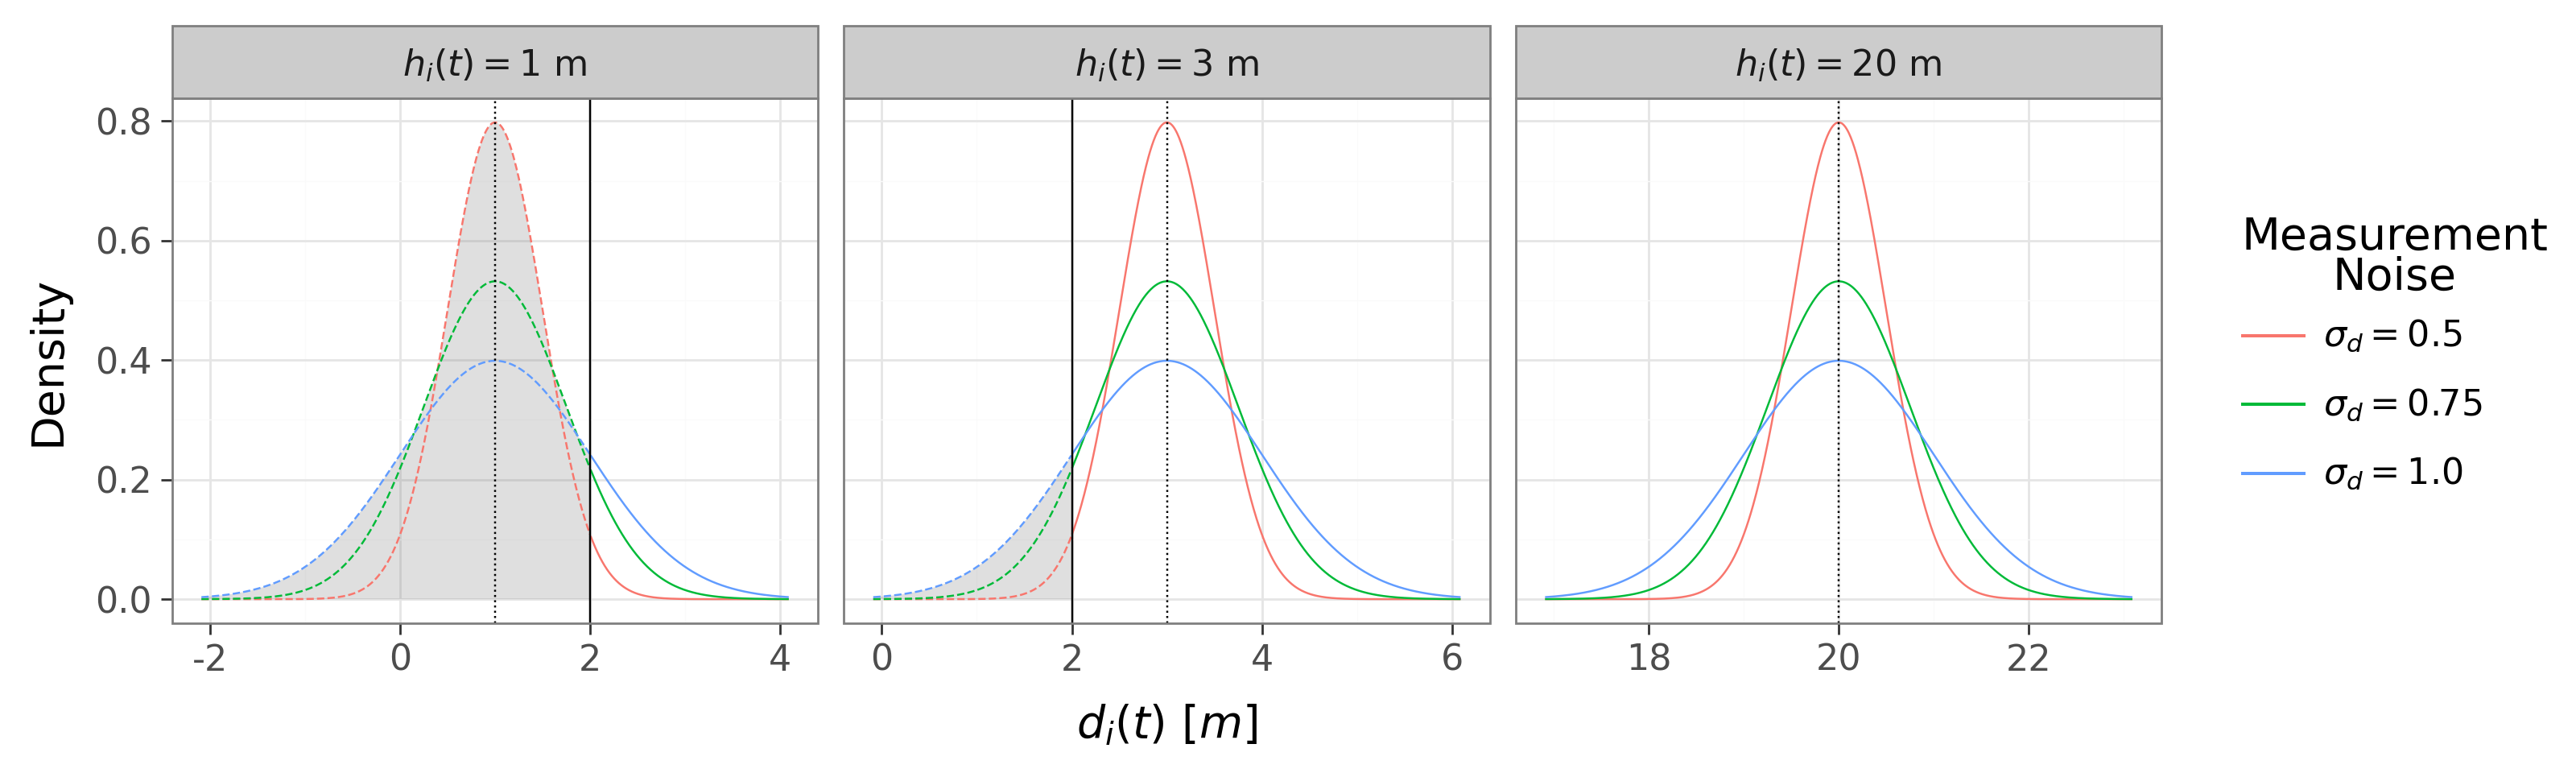

In [3]:
likelihood_plot = plot_likelihood(
    actual_height=np.array((1, 3, 20)),
    height_threshold=2,
    measurement_std=np.array((0.5, 0.75, 1))
)
likelihood_plot.show()

## Propagation of Prior Uncertainty

C:\Users\rasmu\AppData\Roaming\Python\Python313\site-packages\tensorflow_probability\python\internal\vectorization_util.py:87: UserWarning: Saw Tensor seed Tensor("seed:0", shape=(2,), dtype=int32), implying stateless sampling. Autovectorized functions that use stateless sampling may be quite slow because the current implementation falls back to an explicit loop. This will be fixed in the future. For now, you will likely see better performance from stateful sampling, which you can invoke by passing a Python `int` seed.


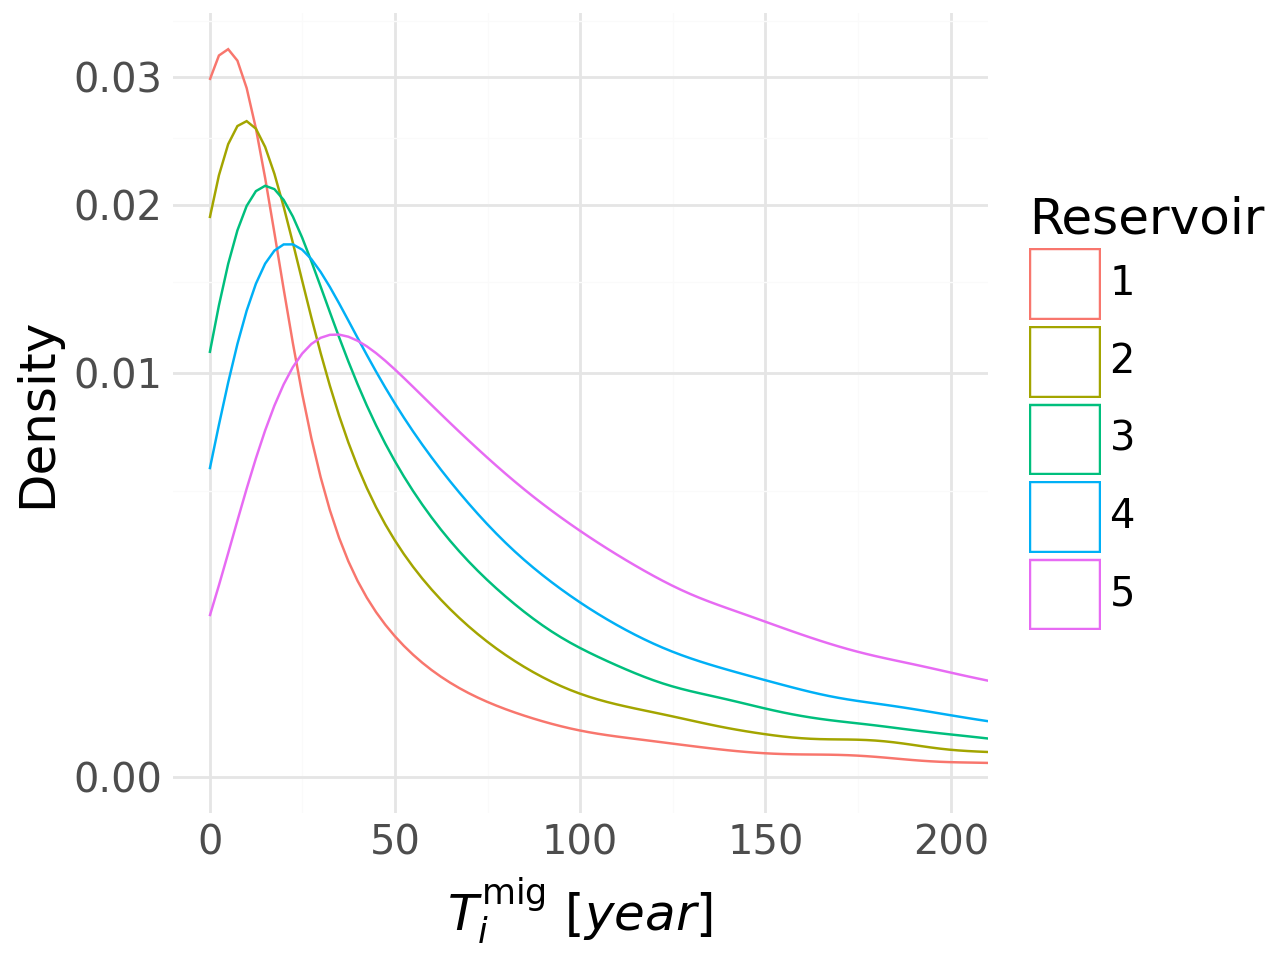

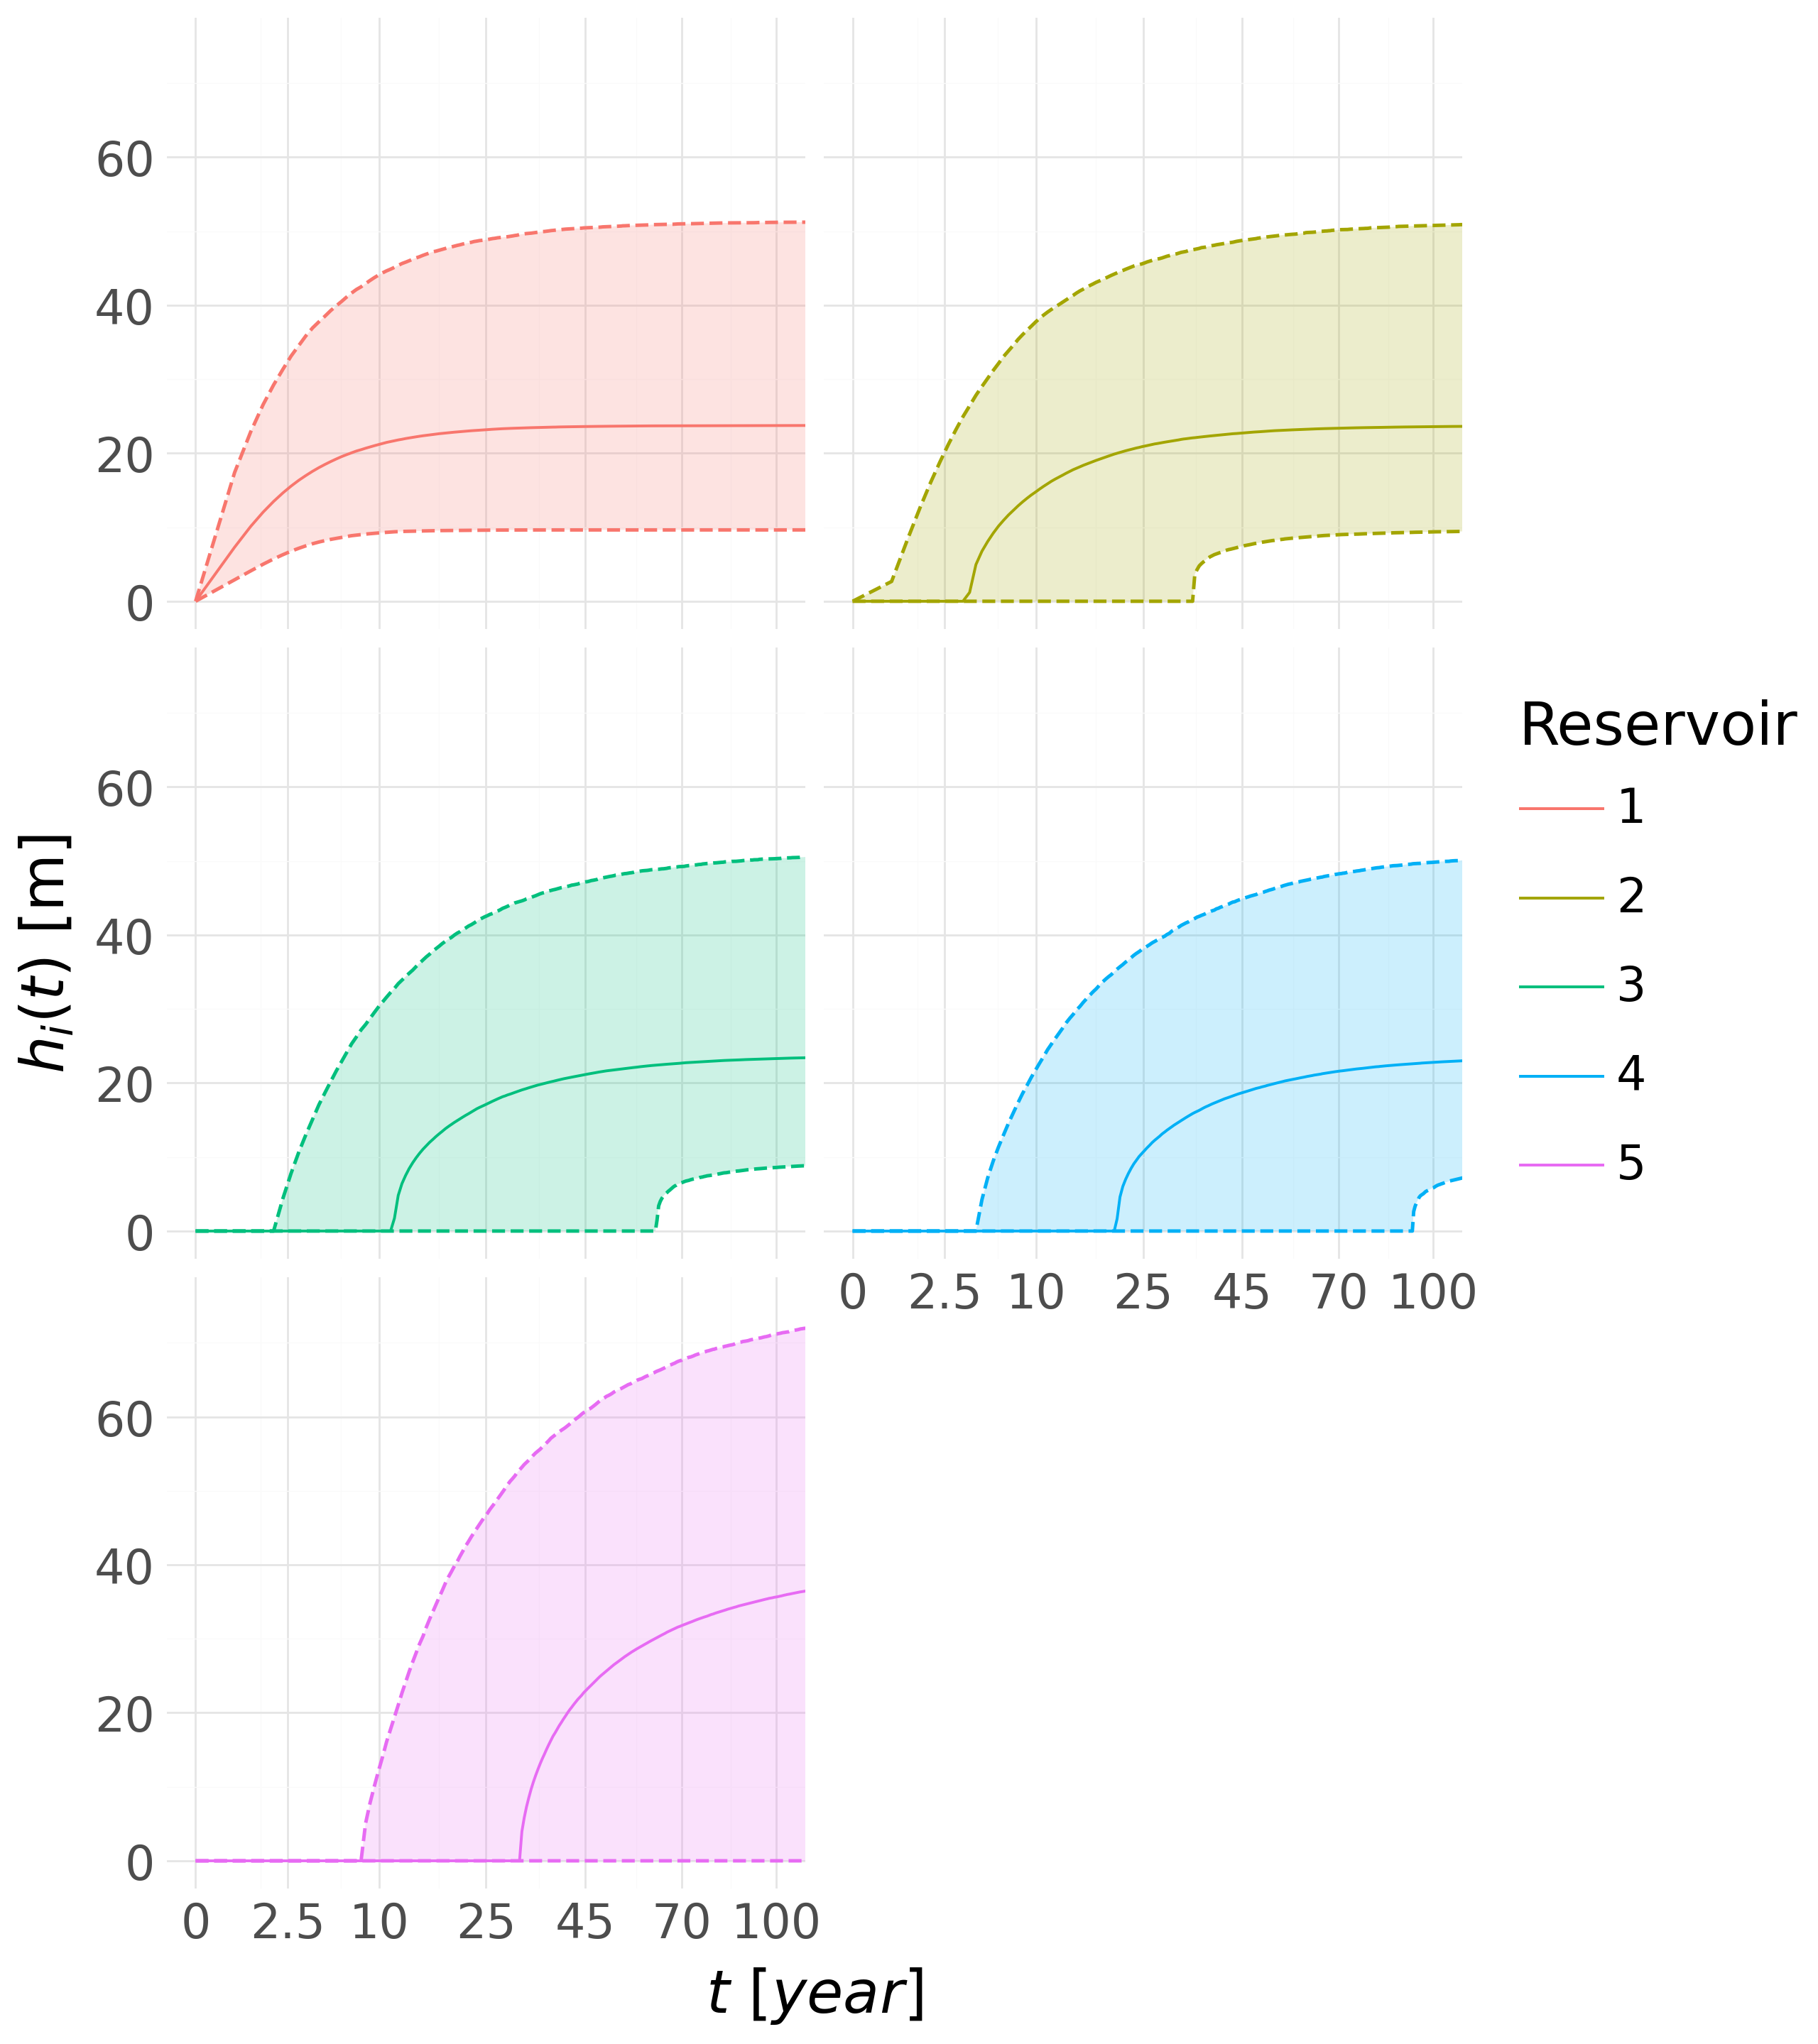

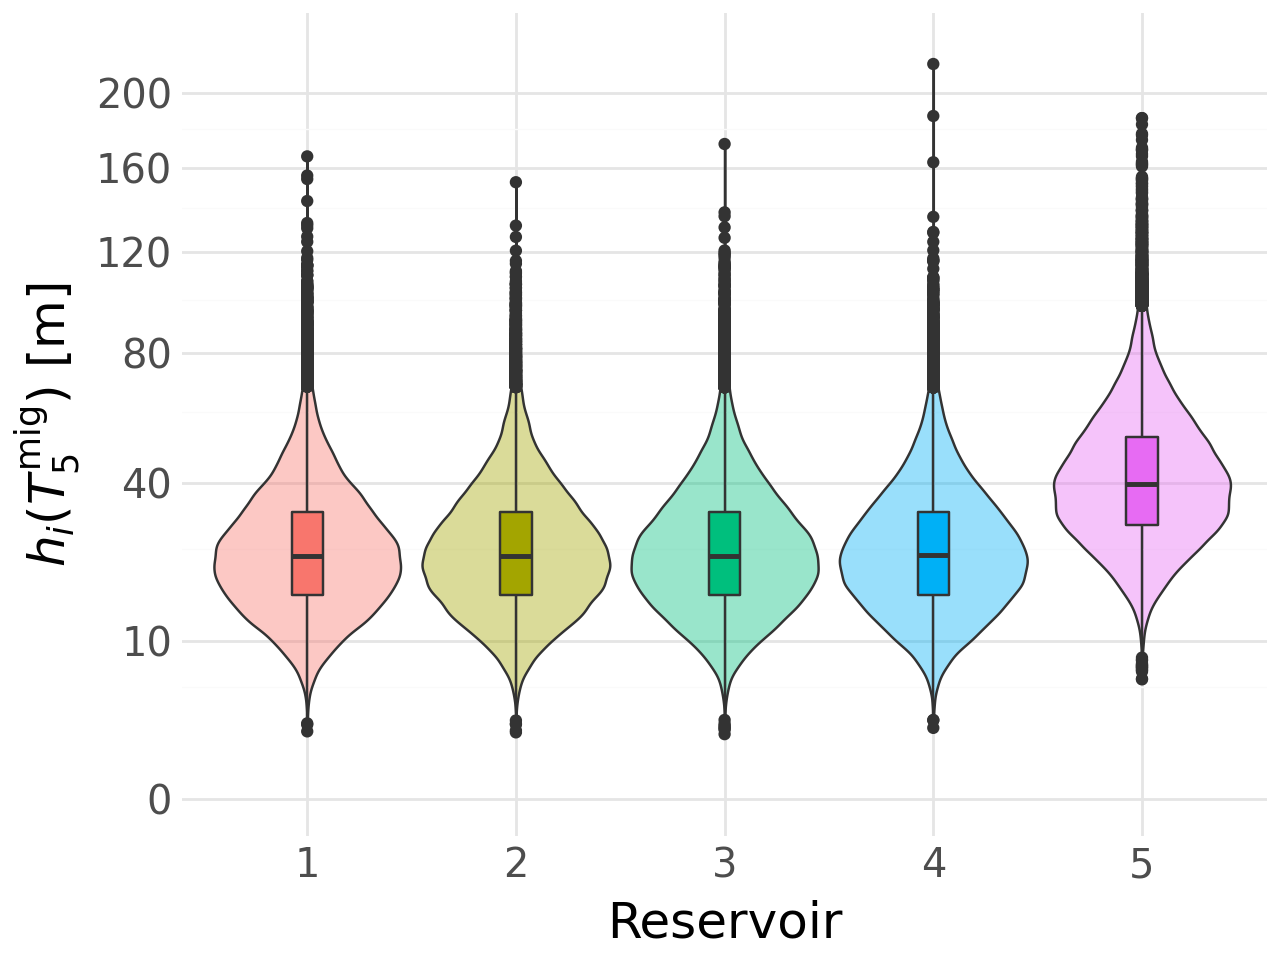

C:\Users\rasmu\AppData\Roaming\Python\Python313\site-packages\tensorflow_probability\python\internal\vectorization_util.py:87: UserWarning: Saw Tensor seed Tensor("seed:0", shape=(2,), dtype=int32), implying stateless sampling. Autovectorized functions that use stateless sampling may be quite slow because the current implementation falls back to an explicit loop. This will be fixed in the future. For now, you will likely see better performance from stateful sampling, which you can invoke by passing a Python `int` seed.


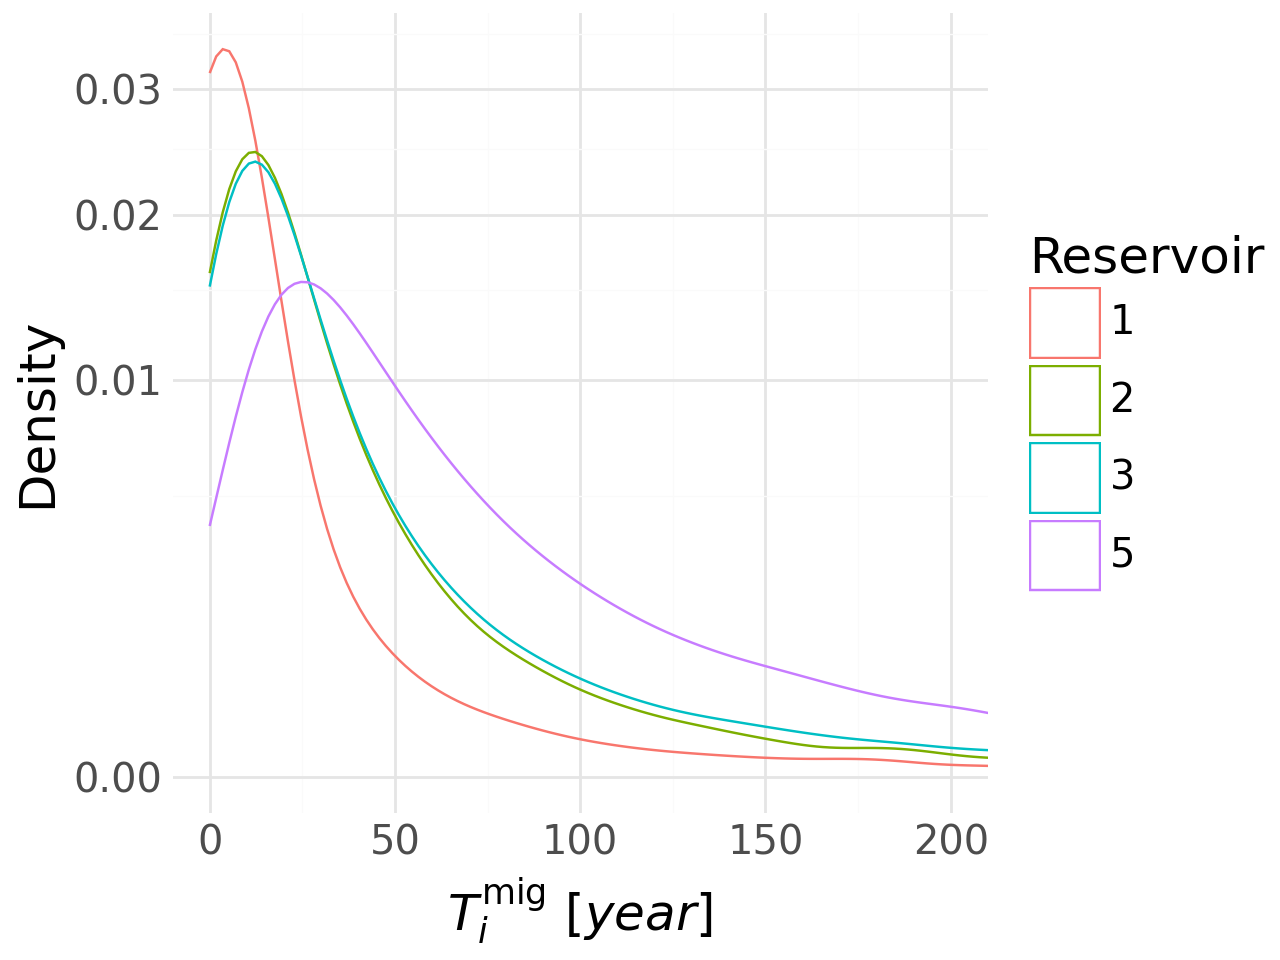

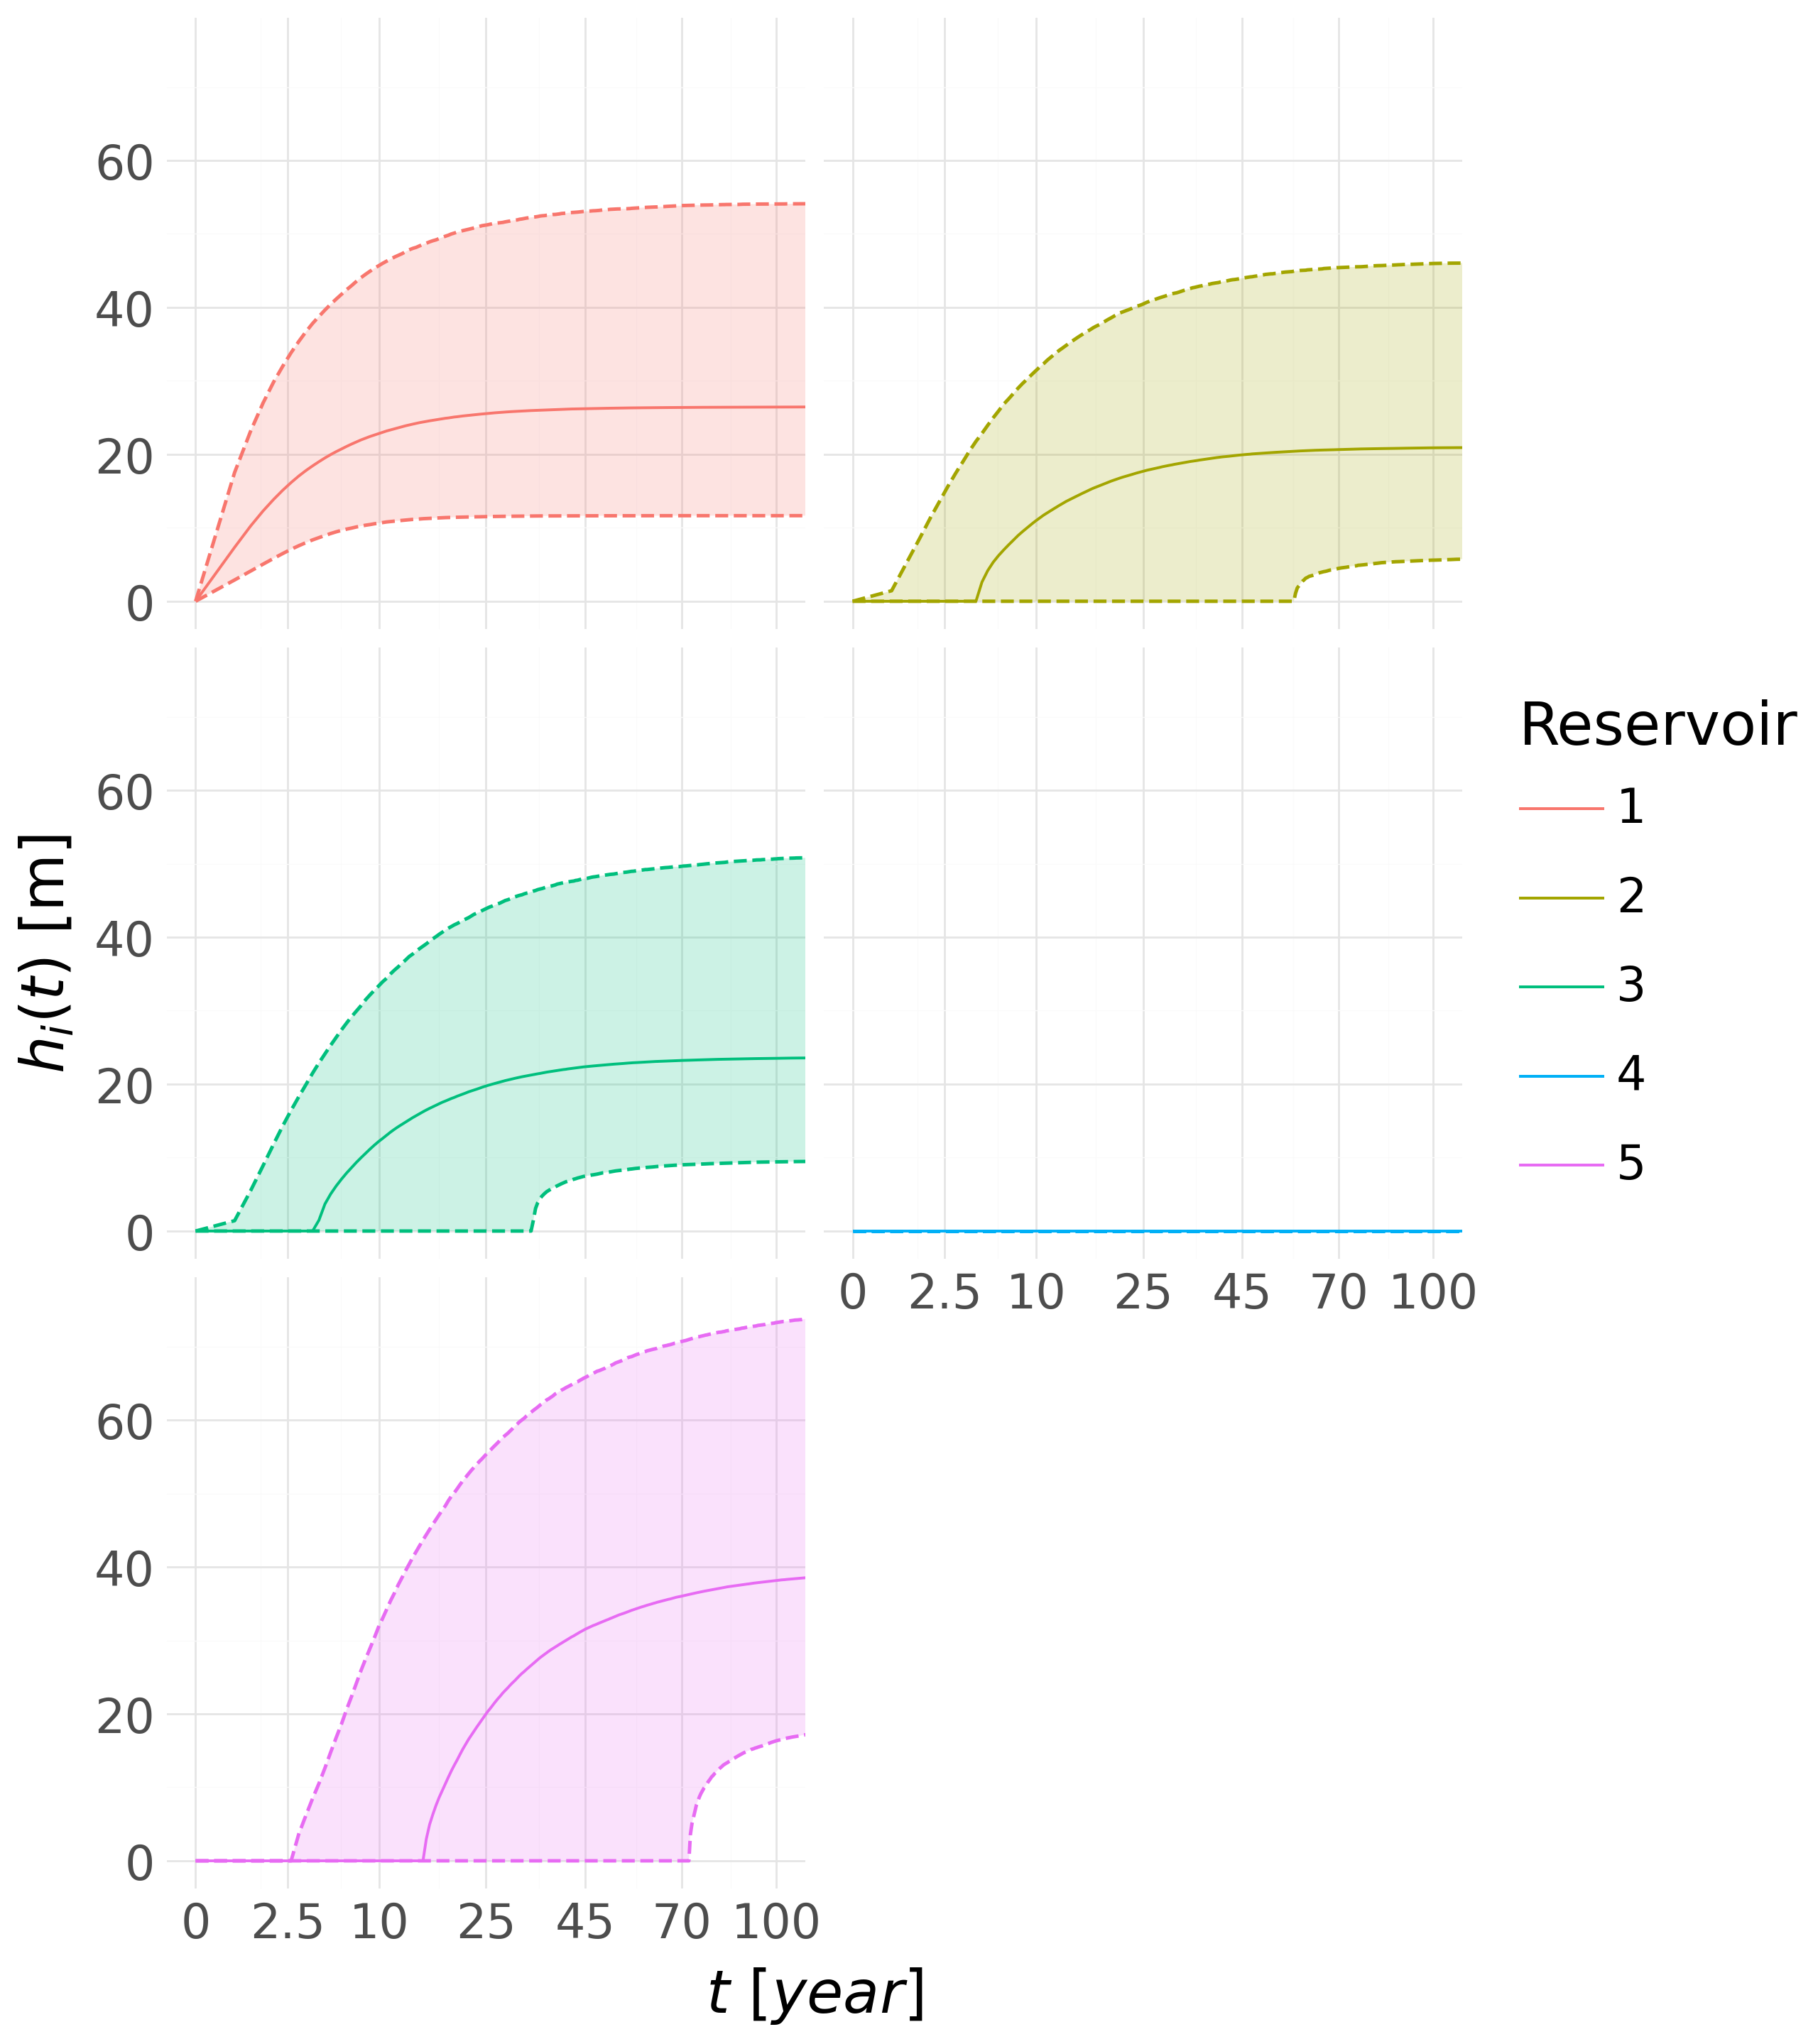

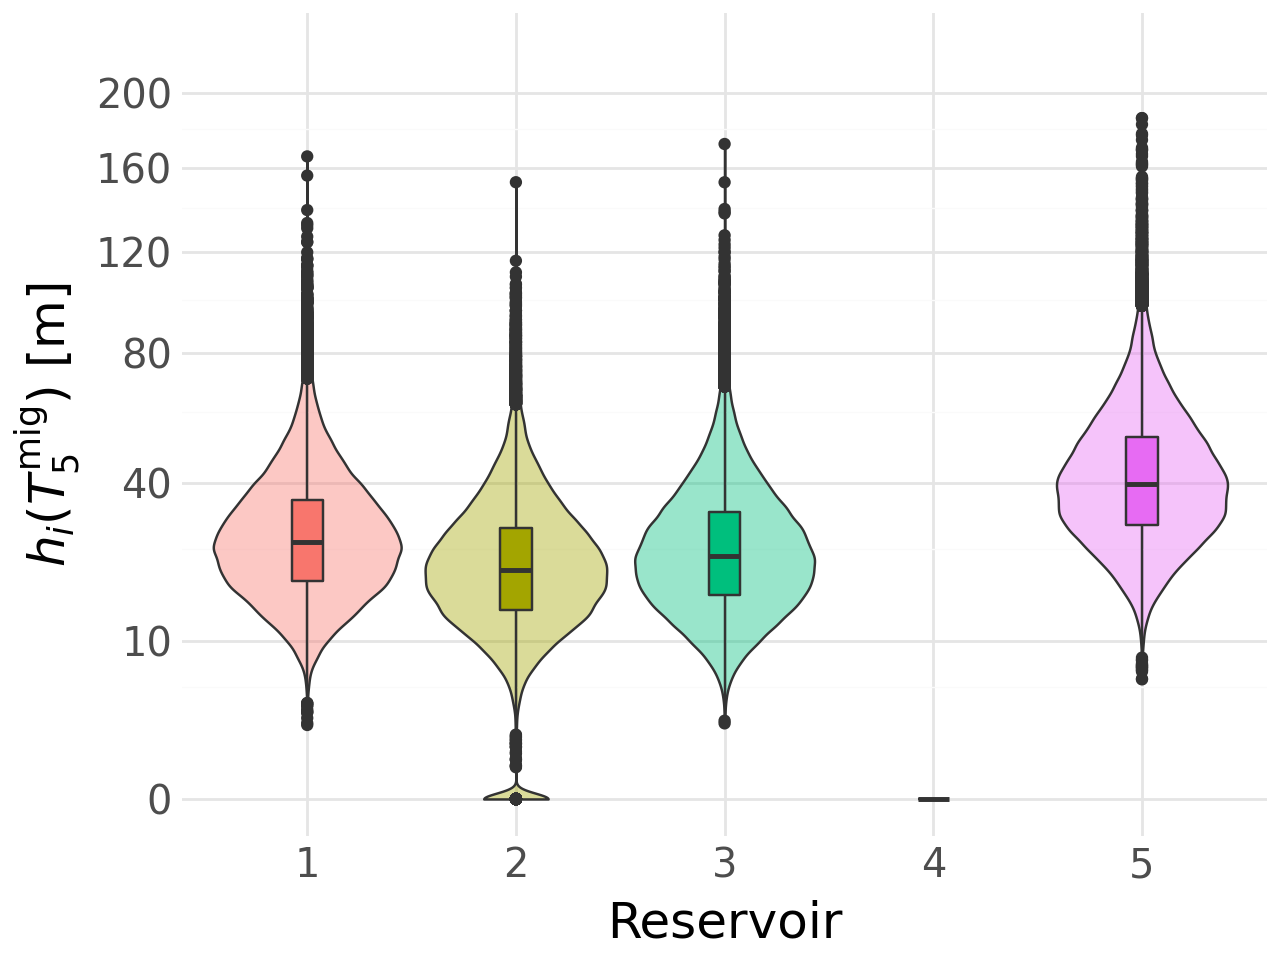

In [4]:
config_path = r"C:\Users\rasmu\TMA4900_final\config.toml"
with open(config_path, "rb") as f:
    config = tomllib.load(f).get("model")

plot(
    config=config, 
    Simulator=Simulator,
    LatentStatePrior=LatentStatePrior,
    graph_encoding=tf.cast(
        tf.constant(config["posterior"]["graphs"][0]),
        dtype=tf.bool
    )
)
plot(
    config=config, 
    Simulator=Simulator,
    LatentStatePrior=LatentStatePrior,
    graph_encoding=tf.cast(
        tf.constant(config["posterior"]["graphs"][1]),
        dtype=tf.bool
    )
)

## Posterior Plots

In [5]:
# sample from posterior
posterior_results = sample_conditional_posteriors(
    config=config,
    ConditionalPosterior=ConditionalPosterior,
    LatentStateKernel=LatentStateKernel,
    num_results=int(
        config["latent_state_kernel"]["number_of_resulting_samples"]
    ),
    num_burnin_steps=int(
        config["latent_state_kernel"]["number_of_burnin_steps"]
    )
)

Currently sampling conditional prior(s) for graph(s):

 [[[0 1 0 0 0]
  [0 0 1 0 0]
  [0 0 0 1 0]
  [0 0 0 0 1]
  [0 0 0 0 0]]

 [[0 1 1 0 0]
  [0 0 1 0 0]
  [0 0 0 0 1]
  [0 0 0 0 1]
  [0 0 0 0 0]]] 

with measured height(s):

 [[[15 0 0 0 0]]

 [[15 0 0 0 0]]] 

at time(s):

 [[2.5]
 [2.5]] 



C:\Users\rasmu\AppData\Roaming\Python\Python313\site-packages\tensorflow_probability\python\internal\vectorization_util.py:87: UserWarning: Saw Tensor seed Tensor("seed:0", shape=(2,), dtype=int32), implying stateless sampling. Autovectorized functions that use stateless sampling may be quite slow because the current implementation falls back to an explicit loop. This will be fixed in the future. For now, you will likely see better performance from stateful sampling, which you can invoke by passing a Python `int` seed.


Currently on step 0, with 12000 steps remaining.
Currently on step 2100, with 9900 steps remaining.
Currently on step 2200, with 9800 steps remaining.
Currently on step 2300, with 9700 steps remaining.
Currently on step 2400, with 9600 steps remaining.
Currently on step 2500, with 9500 steps remaining.
Currently on step 2600, with 9400 steps remaining.
Currently on step 2700, with 9300 steps remaining.
Currently on step 2800, with 9200 steps remaining.
Currently on step 2900, with 9100 steps remaining.
Currently on step 3000, with 9000 steps remaining.
Currently on step 3100, with 8900 steps remaining.
Currently on step 3200, with 8800 steps remaining.
Currently on step 3300, with 8700 steps remaining.
Currently on step 3400, with 8600 steps remaining.
Currently on step 3500, with 8500 steps remaining.
Currently on step 3600, with 8400 steps remaining.
Currently on step 3700, with 8300 steps remaining.
Currently on step 3800, with 8200 steps remaining.
Currently on step 3900, with 8100

C:\Users\rasmu\AppData\Roaming\Python\Python313\site-packages\tensorflow_probability\python\internal\vectorization_util.py:87: UserWarning: Saw Tensor seed Tensor("seed:0", shape=(2,), dtype=int32), implying stateless sampling. Autovectorized functions that use stateless sampling may be quite slow because the current implementation falls back to an explicit loop. This will be fixed in the future. For now, you will likely see better performance from stateful sampling, which you can invoke by passing a Python `int` seed.


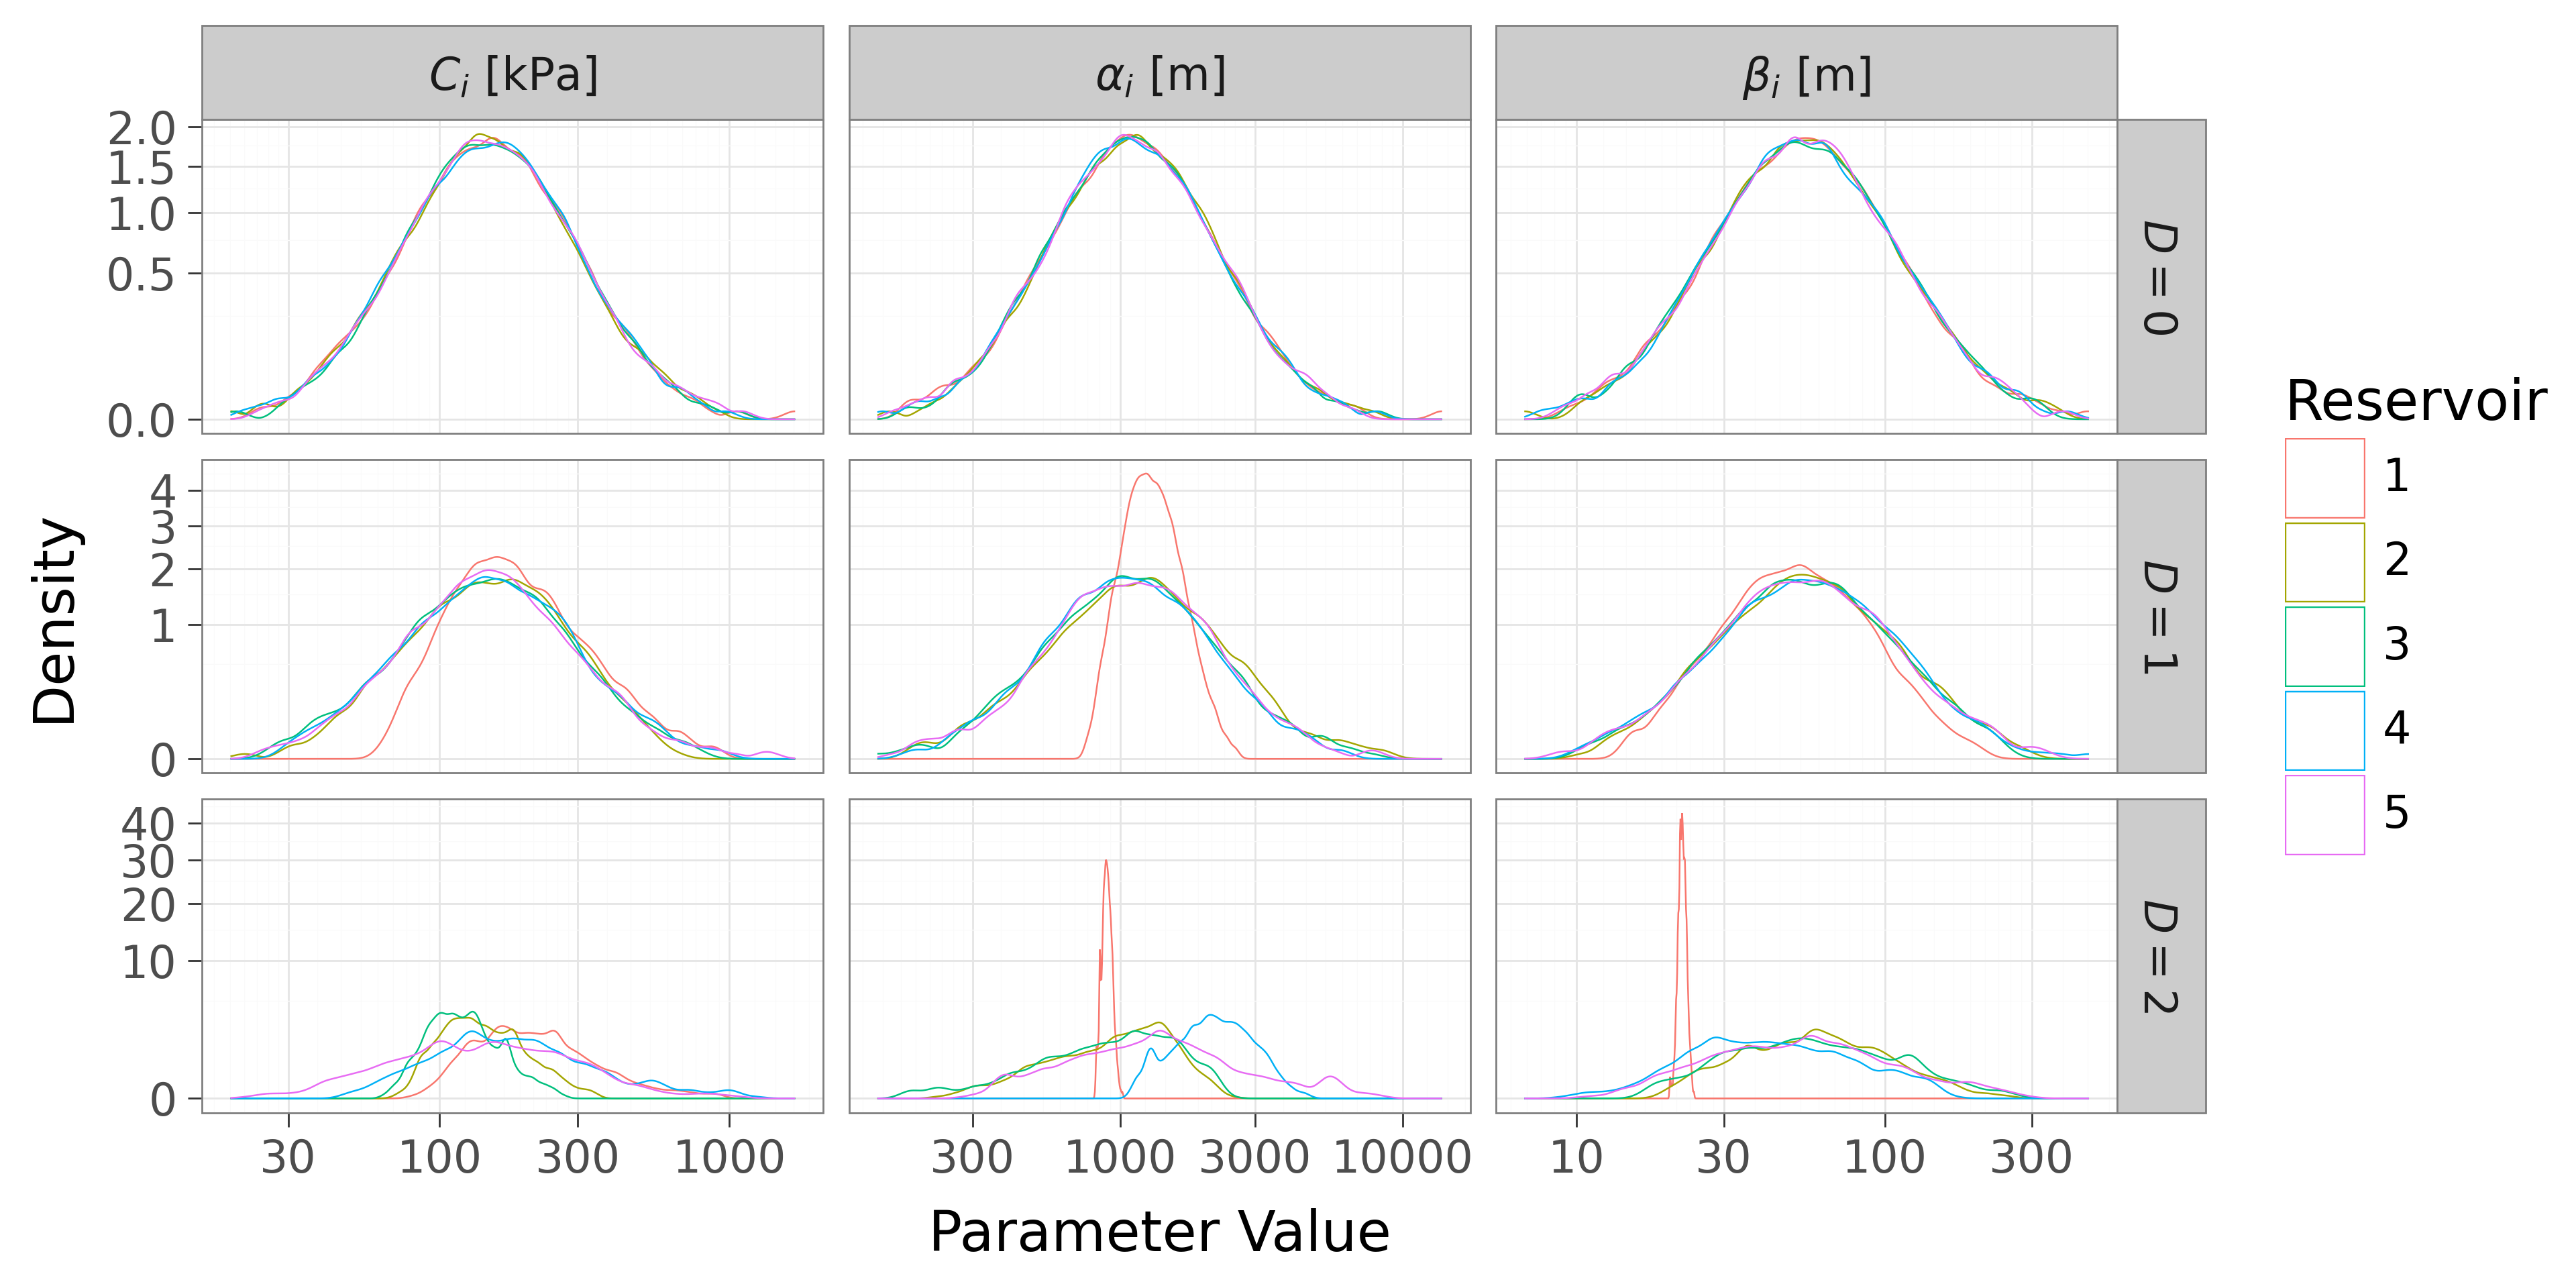

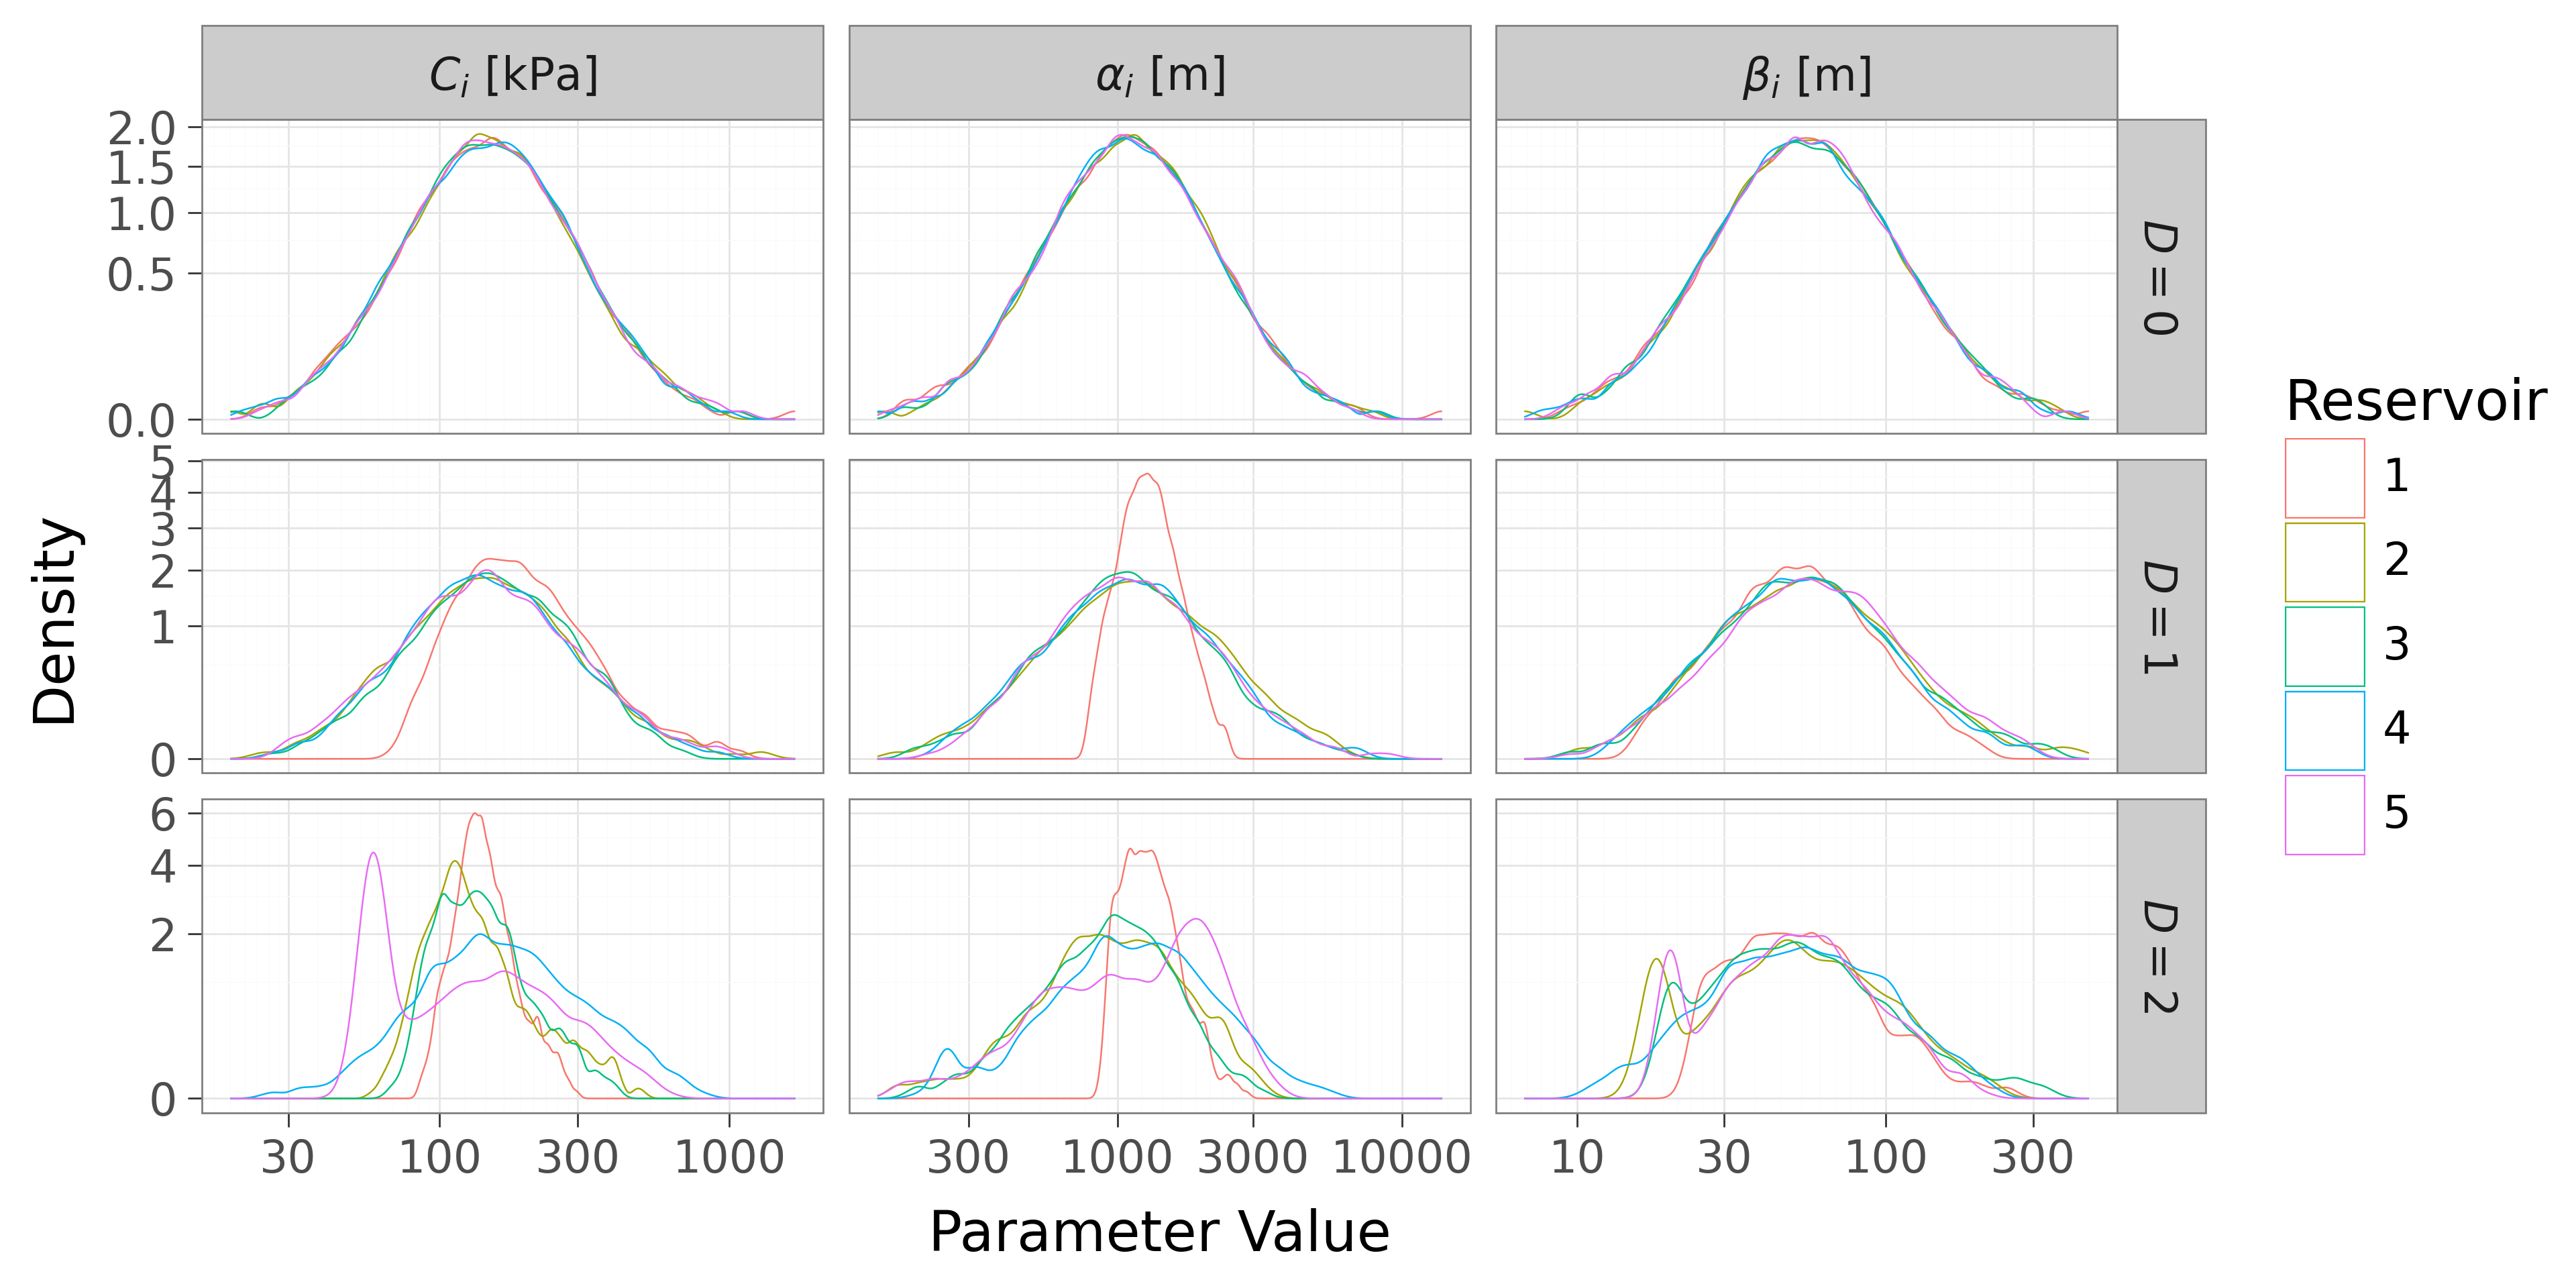

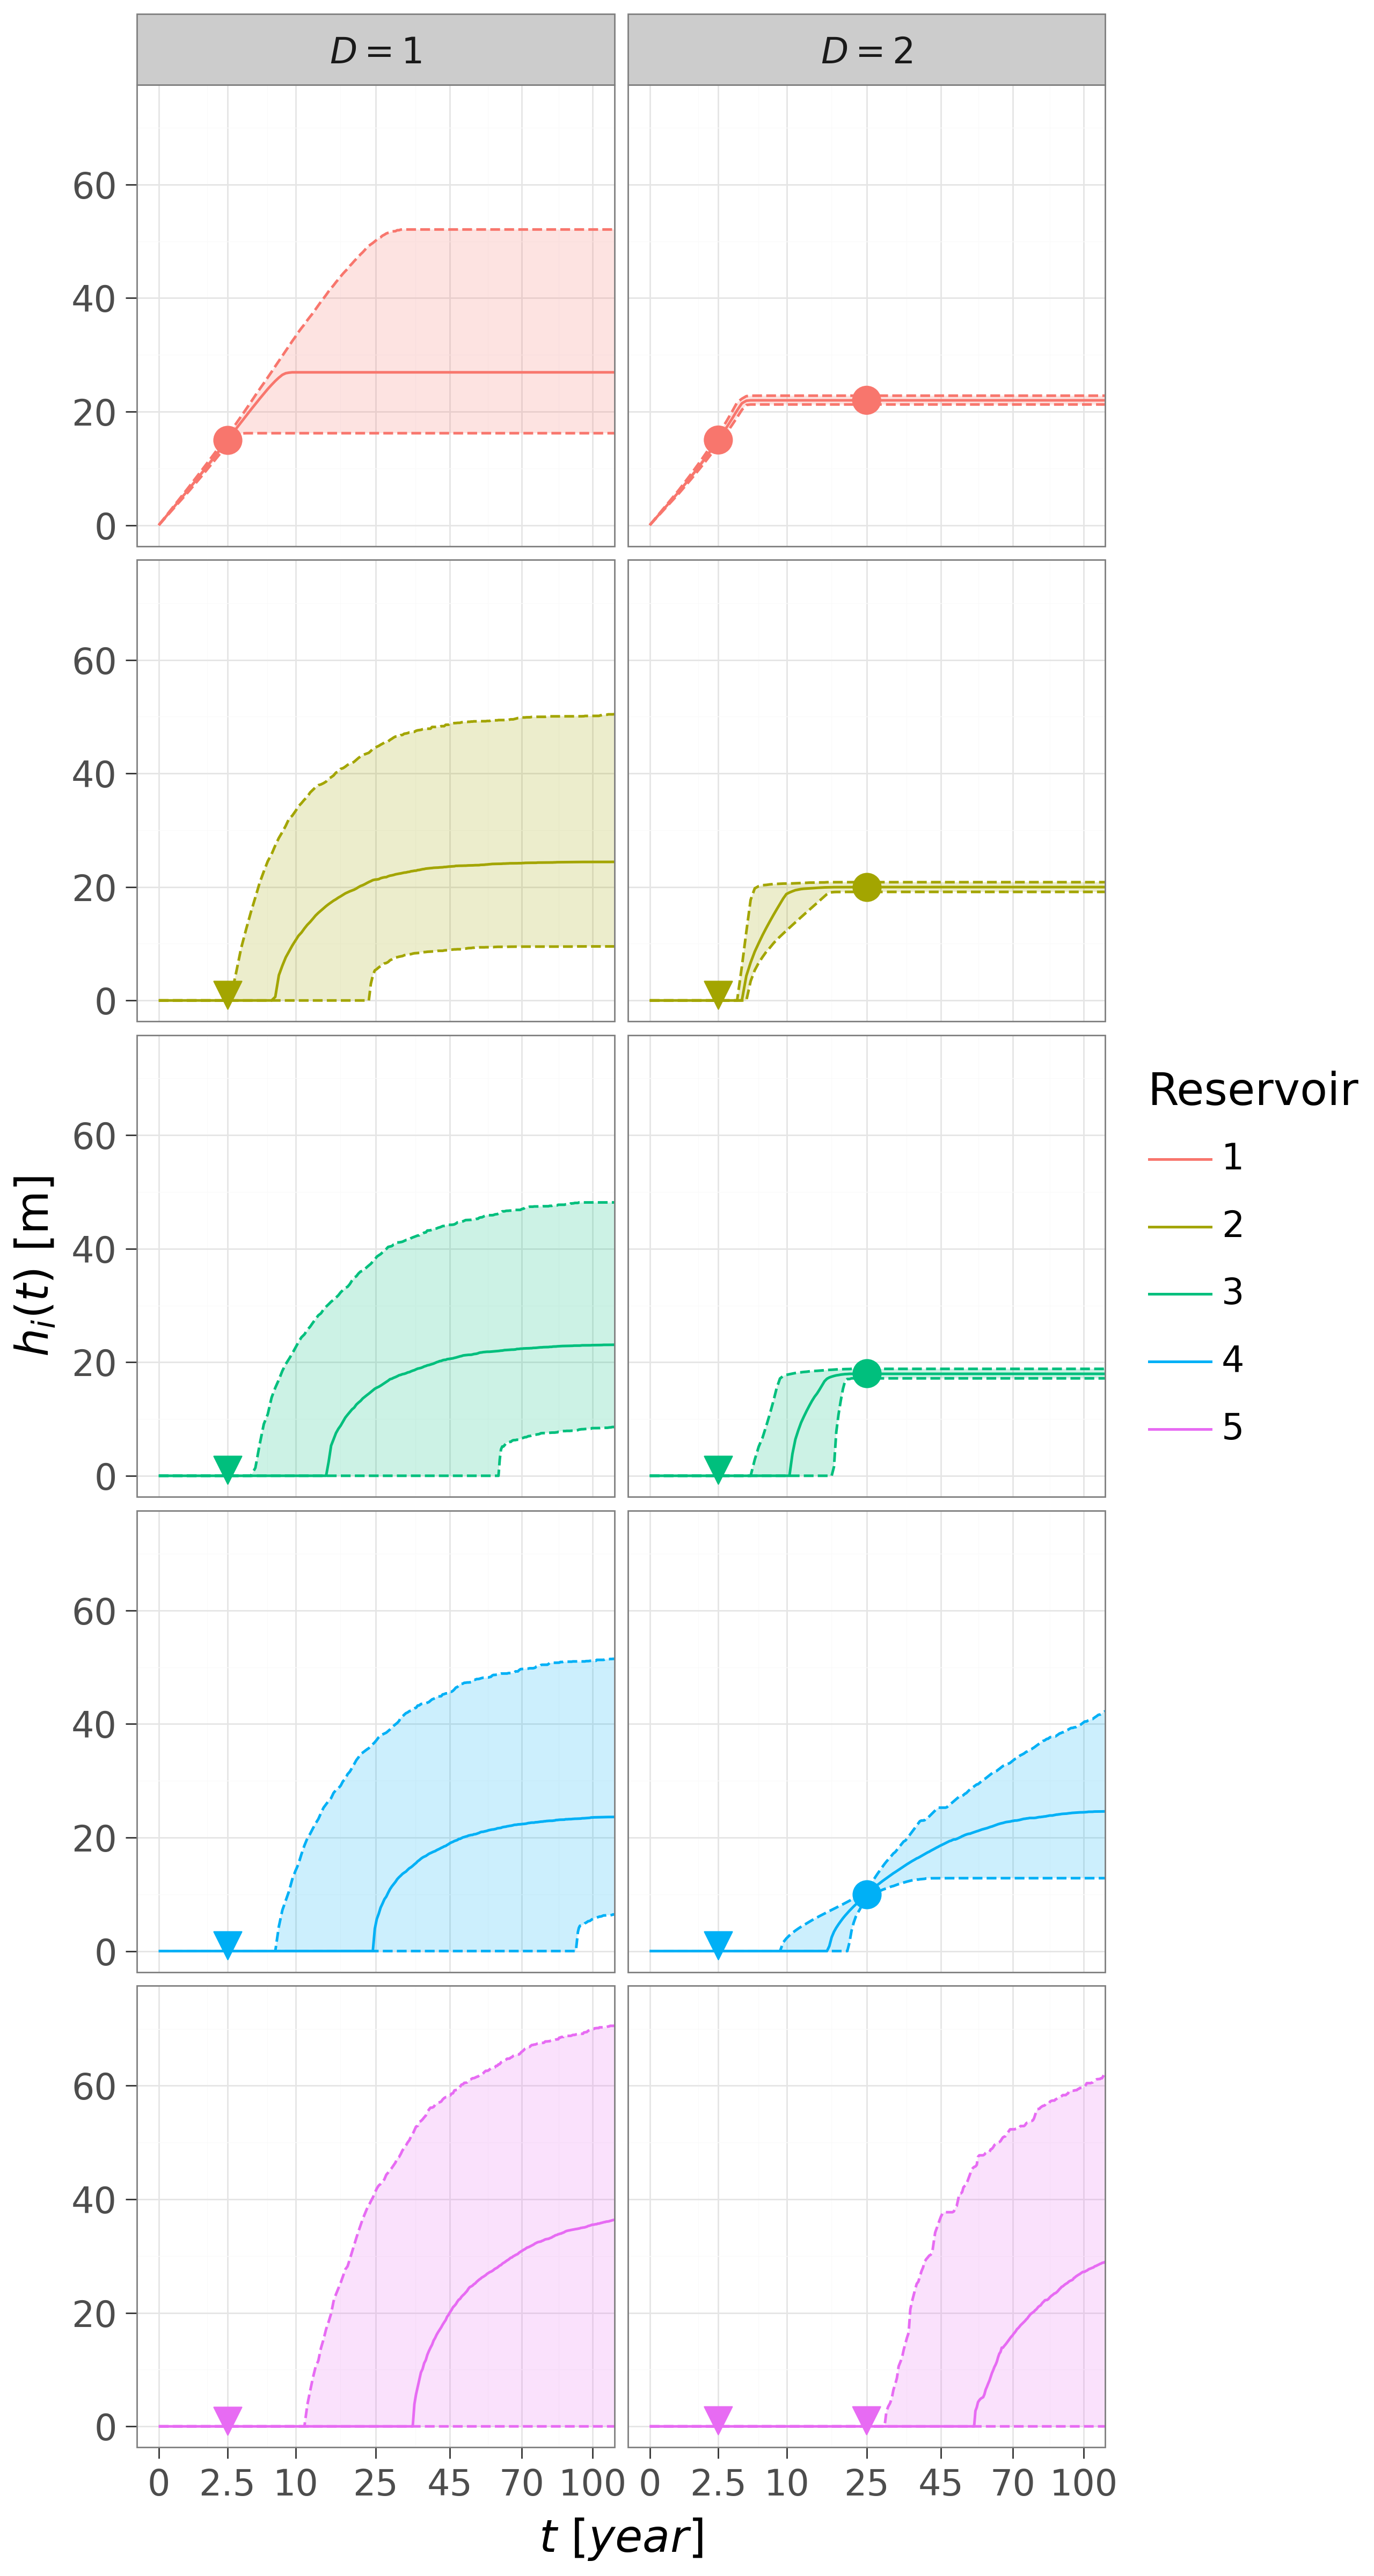

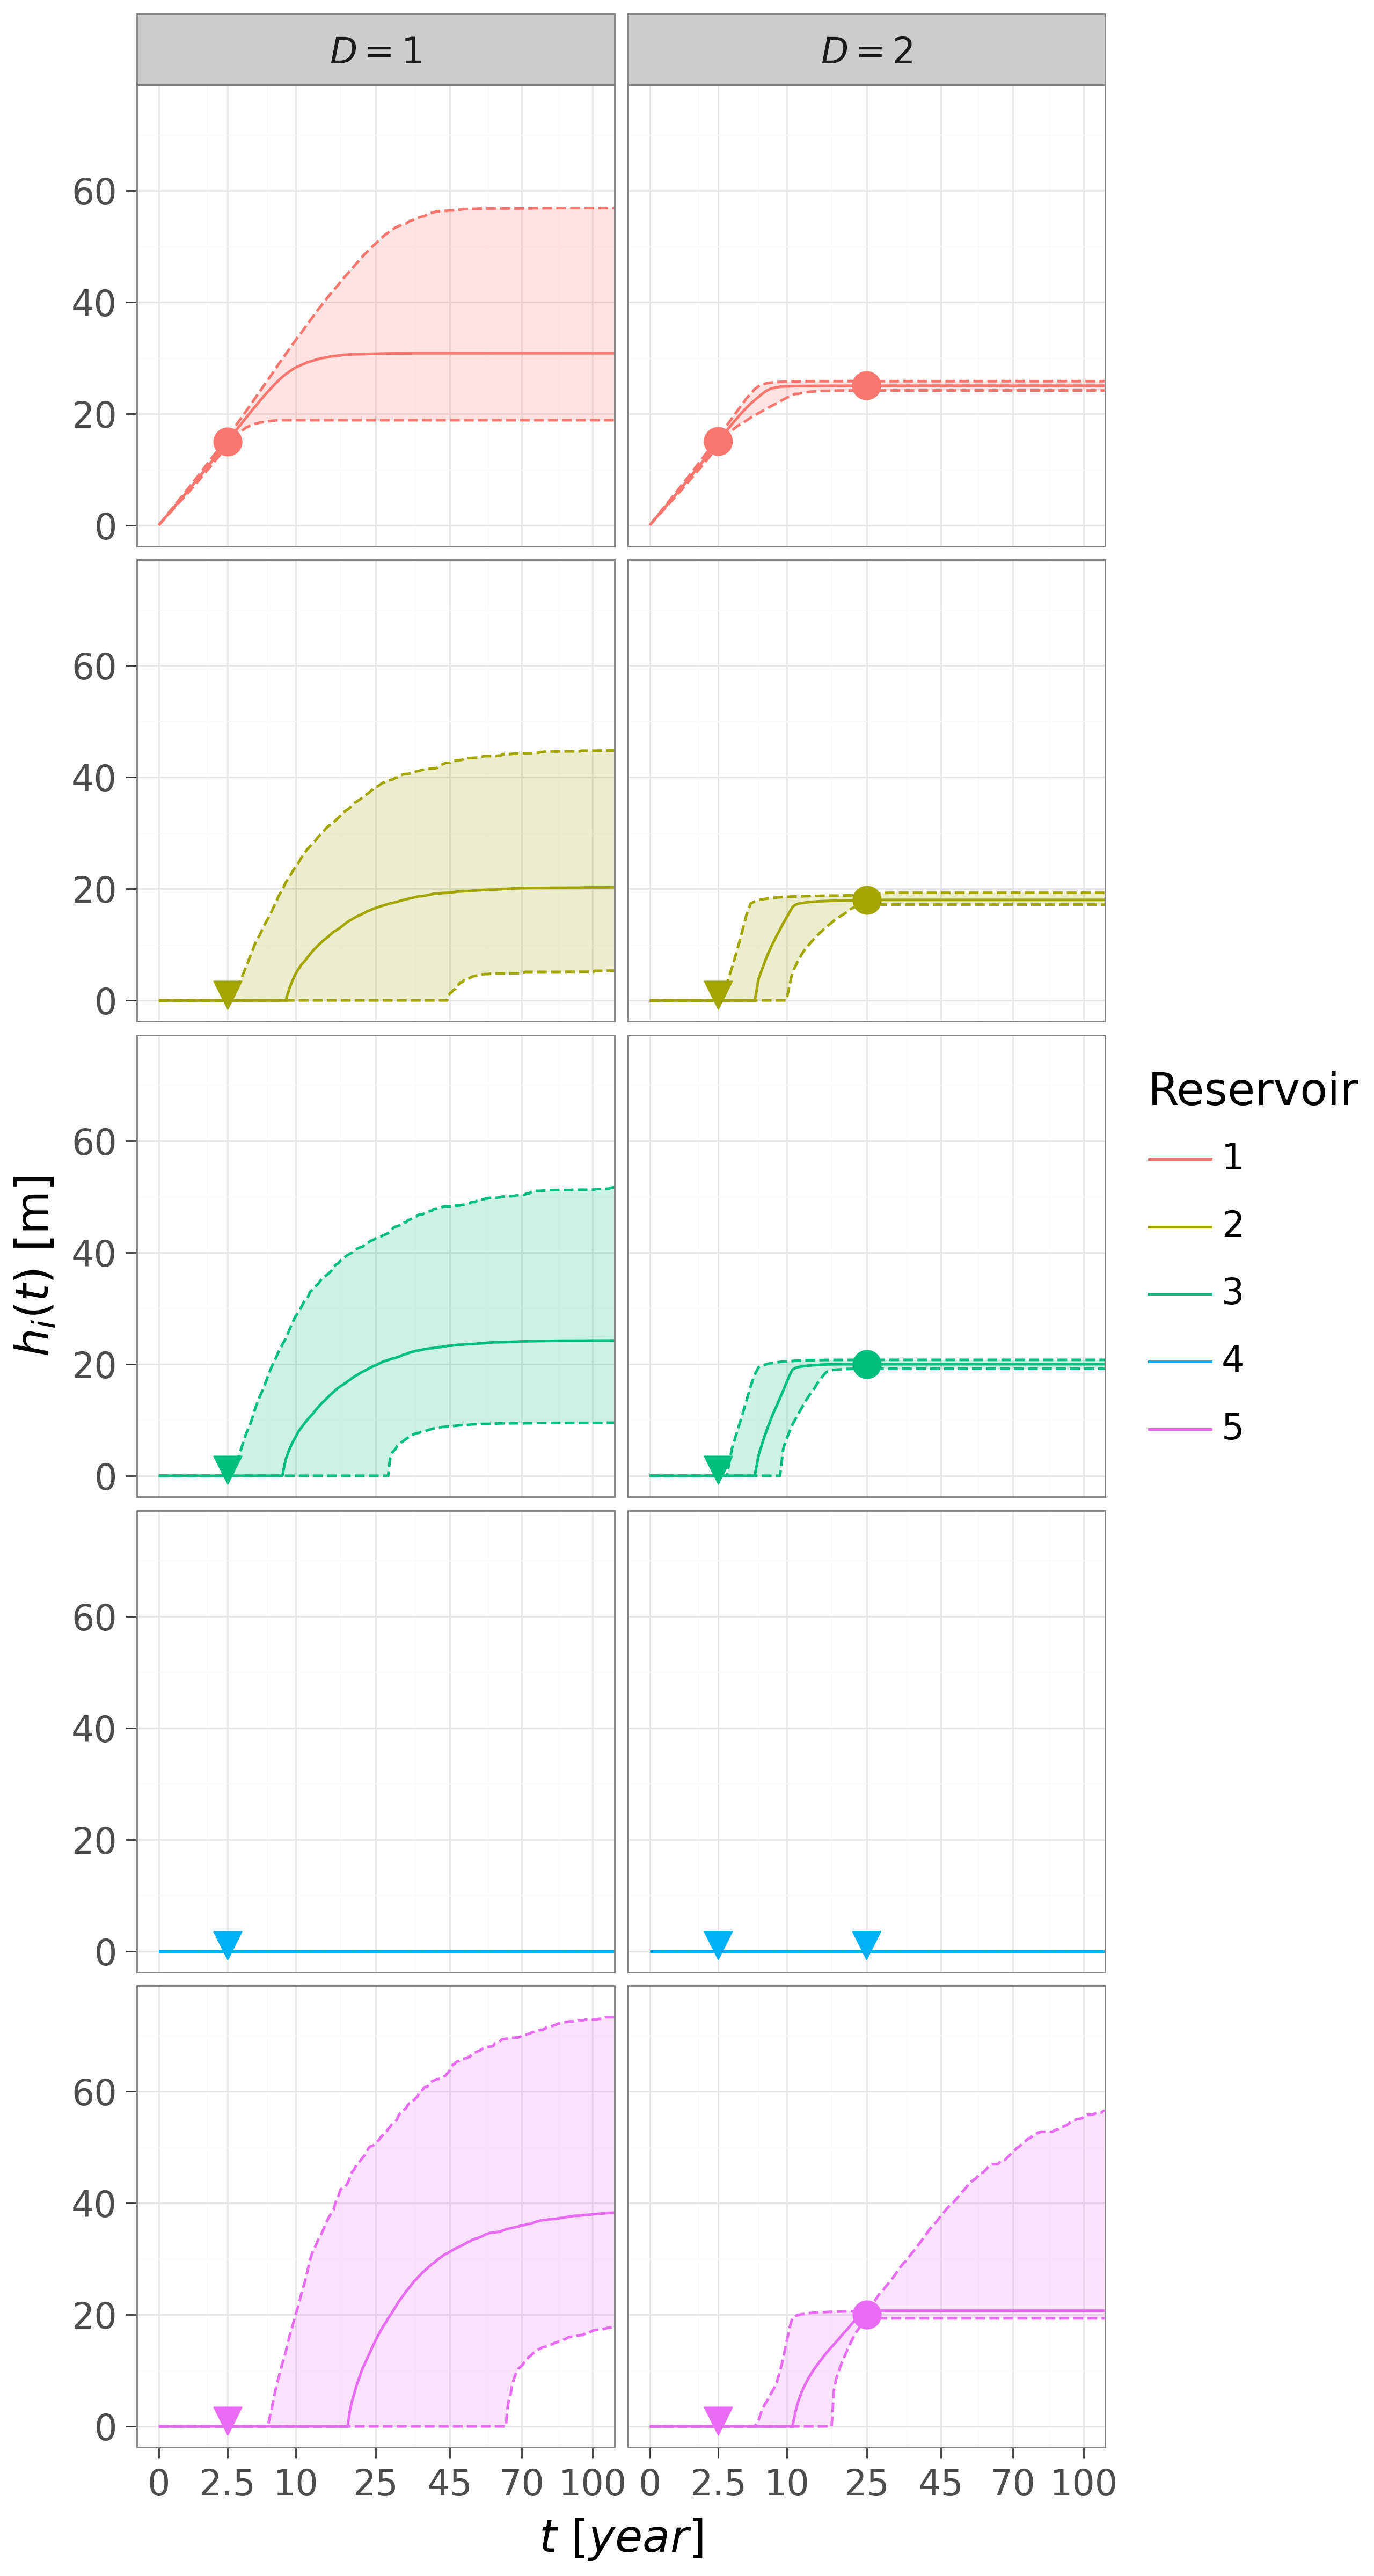

In [6]:
latent_state_prior = LatentStatePrior(config)
latent_prior_samples = latent_state_prior.sample(
    num_samples=int(
        config["latent_state_kernel"]["number_of_resulting_samples"]
    ),
    seed=tf.constant(config["general"]["seed"], dtype=tf.int32)
)

plots = plot_prior_posterior_parameter_density(
    latent_prior_samples=latent_prior_samples, 
    hmc_results=posterior_results
)
for plot in plots:
    plot.show()
    
plots = plot_posterior_height_over_time(
    config=config, 
    posterior_results=posterior_results,
    Simulator=Simulator
)
for plot in plots:
    plot.show()